<a href="https://colab.research.google.com/github/Fentahun60/Fentahun/blob/main/Healthcare_access_Review_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [198]:
import pandas as pd
import gdown

# Google Drive file ID extracted from the provided link
file_id = '1bp8wRfrENq8_92T8M9A6CgshX8C3v-J5'
output_path = 'selected_var_all.dta'

# Download the file from Google Drive
gdown.download(id=file_id, output=output_path, quiet=False)

# Assuming the file is a Stata file (.dta)
df = pd.read_stata(output_path)

# Display the head of the DataFrame
display(df.head())

Downloading...
From: https://drive.google.com/uc?id=1bp8wRfrENq8_92T8M9A6CgshX8C3v-J5
To: /content/selected_var_all.dta
100%|██████████| 15.2M/15.2M [00:00<00:00, 54.3MB/s]


,Country,v001,v005,v007,Maternal_age,highest_educational_level,Residence,sex_of_hh,v157,v158,...,currently_pregnant,History_abortion,contraceptive_use_and_intention,visited_HF_last_12months,v467b,v467c,v467d,v467f,covered_by_health_insurance,Working_status
0,AO7,1,1086089,2016,38,no education,rural,male,not at all,not at all,...,no or unsure,yes,does not intend to use,no,not a big problem,big problem,big problem,not a big problem,no,yes
1,AO7,1,1086089,2016,40,no education,rural,male,not at all,not at all,...,yes,no,does not intend to use,no,not a big problem,not a big problem,not a big problem,not a big problem,no,yes
2,AO7,1,1086089,2016,16,no education,rural,male,not at all,not at all,...,yes,no,does not intend to use,yes,big problem,big problem,not a big problem,not a big problem,no,yes
3,AO7,1,1086089,2016,43,primary,rural,male,not at all,not at all,...,no or unsure,yes,does not intend to use,no,big problem,big problem,not a big problem,not a big problem,no,yes
4,AO7,1,1086089,2016,25,no education,rural,male,not at all,not at all,...,no or unsure,no,does not intend to use,no,not a big problem,not a big problem,not a big problem,not a big problem,no,yes


In [199]:
df.shape


(473294, 25)

In [200]:
# Generate a weighting variable using 'v005'
# v005 is typically the sample weight, often divided by 1,000,000 for normalization
df['Weight'] = df['v005'] / 1000000

# Display the head of the DataFrame with the new 'Weight' column
display(df.head())

,Country,v001,v005,v007,Maternal_age,highest_educational_level,Residence,sex_of_hh,v157,v158,...,History_abortion,contraceptive_use_and_intention,visited_HF_last_12months,v467b,v467c,v467d,v467f,covered_by_health_insurance,Working_status,Weight
0,AO7,1,1086089,2016,38,no education,rural,male,not at all,not at all,...,yes,does not intend to use,no,not a big problem,big problem,big problem,not a big problem,no,yes,1.086089
1,AO7,1,1086089,2016,40,no education,rural,male,not at all,not at all,...,no,does not intend to use,no,not a big problem,not a big problem,not a big problem,not a big problem,no,yes,1.086089
2,AO7,1,1086089,2016,16,no education,rural,male,not at all,not at all,...,no,does not intend to use,yes,big problem,big problem,not a big problem,not a big problem,no,yes,1.086089
3,AO7,1,1086089,2016,43,primary,rural,male,not at all,not at all,...,yes,does not intend to use,no,big problem,big problem,not a big problem,not a big problem,no,yes,1.086089
4,AO7,1,1086089,2016,25,no education,rural,male,not at all,not at all,...,no,does not intend to use,no,not a big problem,not a big problem,not a big problem,not a big problem,no,yes,1.086089


In [201]:
# Create a cross-tabulation of 'Country' and 'v007'
cross_tab = pd.crosstab(df['Country'], df['v007'])

# Display the cross-tabulation
display(cross_tab)

v007,2008,2012,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Country,,,,,,,,,,,,
AO7,0,0,7266,7113,0,0,0,0,0,0,0,0
BF8,0,0,0,0,0,0,0,0,17659,0,0,0
BJ7,0,0,0,0,7387,8541,0,0,0,0,0,0
BU7,0,0,0,10012,7257,0,0,0,0,0,0,0
CD8,0,0,0,0,0,0,0,0,0,0,21684,5899
CI8,0,0,0,0,0,0,0,0,14877,0,0,0
CM7,0,0,0,0,0,14590,87,0,0,0,0,0
ET7,15683,0,0,0,0,0,0,0,0,0,0,0
GA7,0,0,0,0,0,0,911,4695,5437,0,0,0


In [202]:
df.shape

(473294, 26)

In [203]:
# Calculate unweighted and weighted sample sizes for each country
country_sample_sizes = df.groupby('Country').agg(
    unweighted_sample_size=('Country', 'size'),
    weighted_sample_size=('Weight', 'sum')
).reset_index()

# Display the table
display(country_sample_sizes)

,Country,unweighted_sample_size,weighted_sample_size
0,AO7,14379,14379.000241
1,BF8,17659,17658.999988
2,BJ7,15928,15928.000005
3,BU7,17269,17268.999507
4,CD8,27583,27582.999694
5,CI8,14877,14876.999934
6,CM7,14677,14676.999781
7,ET7,15683,15683.000376
8,GA7,11043,11042.999822
9,GH8,15014,15014.000049


In [204]:
# Delete all rows if the country is KM6
df = df[df['Country'] != 'KM6']

# Display the shape of the updated DataFrame to confirm the rows were removed
display(df.shape)

(467965, 26)

In [205]:
# Check for missing values in each column
missing_values = df.isnull().sum()

# Display the number of missing values for each column
display(missing_values)

,0
Country,0
v001,0
v005,0
v007,0
Maternal_age,0
highest_educational_level,0
Residence,0
sex_of_hh,0
v157,8
v158,0


In [206]:
# Create a frequency table for 'v467b'
v467b_counts = df['v467b'].value_counts()

# Display the frequency table
display(v467b_counts)

,count
v467b,
not a big problem,355219
big problem,85736
9.0,0


In [207]:
# Create a frequency table for 'v467b'
v467b_counts = df['v467c'].value_counts()

# Display the frequency table
display(v467b_counts)

,count
v467c,
big problem,231121
not a big problem,209834
9.0,0


In [208]:
# Create a frequency table for 'v467b'
v467d_counts = df['v467d'].value_counts()

# Display the frequency table
display(v467d_counts)

,count
v467d,
not a big problem,280193
big problem,160762
9.0,0


In [209]:
# Create a frequency table for 'v467b'
v467f_counts = df['v467f'].value_counts()

# Display the frequency table
display(v467f_counts)

,count
v467f,
not a big problem,340170
big problem,100785
9.0,0


In [210]:
# Calculate the percentage of missing values for the specified columns
missing_percentage_v467b = (df['v467b'].isnull().sum() / len(df)) * 100
missing_percentage_v467c = (df['v467c'].isnull().sum() / len(df)) * 100
missing_percentage_v467d = (df['v467d'].isnull().sum() / len(df)) * 100
missing_percentage_v467f = (df['v467f'].isnull().sum() / len(df)) * 100

# Display the percentage of missing values
print(f"Percentage of missing values in 'v467b': {missing_percentage_v467b:.2f}%")
print(f"Percentage of missing values in 'v467c': {missing_percentage_v467c:.2f}%")
print(f"Percentage of missing values in 'v467d': {missing_percentage_v467d:.2f}%")
print(f"Percentage of missing values in 'v467f': {missing_percentage_v467f:.2f}%")

Percentage of missing values in 'v467b': 5.77%
Percentage of missing values in 'v467c': 5.77%
Percentage of missing values in 'v467d': 5.77%
Percentage of missing values in 'v467f': 5.77%


In [211]:
# Group by 'Country' and calculate the number of missing values for the specified columns
missing_values_by_country = df.groupby('Country')[['v467b', 'v467c', 'v467d', 'v467f']].apply(lambda x: x.isnull().sum())

# Calculate the total number of rows for each country
total_rows_by_country = df.groupby('Country').size()

# Calculate the percentage of missing values by country
missing_percentage_by_country = missing_values_by_country.divide(total_rows_by_country, axis=0) * 100

# Display the number of missing values by country
print("Number of missing values by Country:")
display(missing_values_by_country)

# Display the percentage of missing values by country
print("\nPercentage of missing values by Country:")
display(missing_percentage_by_country)

Number of missing values by Country:


,v467b,v467c,v467d,v467f
Country,,,,
AO7,0,0,0,0
BF8,0,0,0,0
BJ7,0,0,0,0
BU7,0,0,0,0
CD8,0,0,0,0
CI8,0,0,0,0
CM7,1150,1150,1150,1150
ET7,0,0,0,0
GA7,3132,3132,3132,3132



Percentage of missing values by Country:


,v467b,v467c,v467d,v467f
Country,,,,
AO7,0.000000,0.000000,0.000000,0.000000
BF8,0.000000,0.000000,0.000000,0.000000
BJ7,0.000000,0.000000,0.000000,0.000000
BU7,0.000000,0.000000,0.000000,0.000000
CD8,0.000000,0.000000,0.000000,0.000000
CI8,0.000000,0.000000,0.000000,0.000000
CM7,7.835389,7.835389,7.835389,7.835389
ET7,0.000000,0.000000,0.000000,0.000000
GA7,28.361858,28.361858,28.361858,28.361858


In [212]:
# Create a new column 'Problems in Accessing Health Care'
# It will be 'big problem' if any of the specified columns have 'big problem', otherwise 'not a big problem'
df['Problem_Access'] = df[['v467b', 'v467c', 'v467d', 'v467f']].apply(
    lambda row: 'big problem' if (row == 'big problem').any() else 'not a big problem', axis=1
)

# Calculate unweighted value counts
unweighted_counts = df['Problem_Access'].value_counts()

# Calculate weighted value counts
weighted_counts = df.groupby('Problem_Access')['Weight'].sum()

# Calculate unweighted and weighted percentages
unweighted_percentages = df['Problem_Access'].value_counts(normalize=True) * 100
weighted_percentages = df.groupby('Problem_Access').apply(lambda x: (x['Weight'].sum() / df['Weight'].sum()) * 100)

# Combine all into a single DataFrame
comparison_table = pd.DataFrame({
    'Unweighted Count': unweighted_counts,
    'Weighted Count': weighted_counts,
    'Unweighted Percentage (%)': unweighted_percentages,
    'Weighted Percentage (%)': weighted_percentages
})

# Display the combined table
display(comparison_table)

/tmp/ipykernel_1158/2319183211.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_percentages = df.groupby('Problem_Access').apply(lambda x: (x['Weight'].sum() / df['Weight'].sum()) * 100)


,Unweighted Count,Weighted Count,Unweighted Percentage (%),Weighted Percentage (%)
Problem_Access,,,,
big problem,273446,269149.669594,58.433002,57.514915
not a big problem,194519,198815.329849,41.566998,42.485085


In [213]:
df.head()

,Country,v001,v005,v007,Maternal_age,highest_educational_level,Residence,sex_of_hh,v157,v158,...,contraceptive_use_and_intention,visited_HF_last_12months,v467b,v467c,v467d,v467f,covered_by_health_insurance,Working_status,Weight,Problem_Access
0,AO7,1,1086089,2016,38,no education,rural,male,not at all,not at all,...,does not intend to use,no,not a big problem,big problem,big problem,not a big problem,no,yes,1.086089,big problem
1,AO7,1,1086089,2016,40,no education,rural,male,not at all,not at all,...,does not intend to use,no,not a big problem,not a big problem,not a big problem,not a big problem,no,yes,1.086089,not a big problem
2,AO7,1,1086089,2016,16,no education,rural,male,not at all,not at all,...,does not intend to use,yes,big problem,big problem,not a big problem,not a big problem,no,yes,1.086089,big problem
3,AO7,1,1086089,2016,43,primary,rural,male,not at all,not at all,...,does not intend to use,no,big problem,big problem,not a big problem,not a big problem,no,yes,1.086089,big problem
4,AO7,1,1086089,2016,25,no education,rural,male,not at all,not at all,...,does not intend to use,no,not a big problem,not a big problem,not a big problem,not a big problem,no,yes,1.086089,not a big problem


In [214]:
# Create a frequency table for 'v157'
v157_counts = df['v157'].value_counts()

# Display the frequency table
display(v157_counts)

,count
v157,
not at all,398088
less than once a week,41560
at least once a week,27465
almost every day,844
9.0,0


In [215]:
# Define the conditions for 'Yes' and 'No'
yes_conditions = ['at least once a week', 'almost every day']

# Create 'Media exposure' based on v157, v158, v159
# Note: This requires the original columns to be present.
# If they were dropped previously, this will need to be run before the drop command.
df['Media exposure'] = df[['v157', 'v158', 'v159']].apply(
    lambda row: 'Yes' if any(item in yes_conditions for item in row) else 'No', axis=1
)

# Calculate unweighted counts and percentages
unweighted_counts = df['Media exposure'].value_counts()
unweighted_pct = df['Media exposure'].value_counts(normalize=True) * 100

# Calculate weighted counts and percentages
weighted_counts = df.groupby('Media exposure')['Weight'].sum()
weighted_pct = (weighted_counts / df['Weight'].sum()) * 100

# Combine into a single table
media_comparison = pd.DataFrame({
    'Unweighted Count': unweighted_counts,
    'Weighted Count': weighted_counts,
    'Unweighted %': unweighted_pct,
    'Weighted %': weighted_pct
})

# Display results
print("Comparison of Unweighted and Weighted Media Exposure:")
display(media_comparison)

Comparison of Unweighted and Weighted Media Exposure:


,Unweighted Count,Weighted Count,Unweighted %,Weighted %
Media exposure,,,,
No,237080,227167.847021,50.661908,48.543769
Yes,230885,240797.152422,49.338092,51.456231


In [216]:
df.head()

,Country,v001,v005,v007,Maternal_age,highest_educational_level,Residence,sex_of_hh,v157,v158,...,visited_HF_last_12months,v467b,v467c,v467d,v467f,covered_by_health_insurance,Working_status,Weight,Problem_Access,Media exposure
0,AO7,1,1086089,2016,38,no education,rural,male,not at all,not at all,...,no,not a big problem,big problem,big problem,not a big problem,no,yes,1.086089,big problem,No
1,AO7,1,1086089,2016,40,no education,rural,male,not at all,not at all,...,no,not a big problem,not a big problem,not a big problem,not a big problem,no,yes,1.086089,not a big problem,No
2,AO7,1,1086089,2016,16,no education,rural,male,not at all,not at all,...,yes,big problem,big problem,not a big problem,not a big problem,no,yes,1.086089,big problem,No
3,AO7,1,1086089,2016,43,primary,rural,male,not at all,not at all,...,no,big problem,big problem,not a big problem,not a big problem,no,yes,1.086089,big problem,No
4,AO7,1,1086089,2016,25,no education,rural,male,not at all,not at all,...,no,not a big problem,not a big problem,not a big problem,not a big problem,no,yes,1.086089,not a big problem,No


In [217]:
# Check for missing values in each column
missing_values = df.isnull().sum()

# Calculate the percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Create a DataFrame to display both counts and percentages
missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

# Display the missing values information, sorted by count in descending order
display(missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))


,Missing Count,Missing Percentage
covered_by_health_insurance,43911,9.383394
visited_HF_last_12months,27047,5.779706
v467b,27010,5.771799
v467c,27010,5.771799
v467f,27010,5.771799
v467d,27010,5.771799
currently_pregnant,5838,1.247529
gave_birth_in_the_5yrs,5838,1.247529
contraceptive_use_and_intention,5838,1.247529
History_abortion,5838,1.247529


In [218]:
# Drop the specified columns
df = df.drop(columns=['v467b', 'v467c', 'v467d', 'v467f', 'v157', 'v158', 'v159'])

# Display the head of the DataFrame to confirm the columns were dropped
display(df.head())

,Country,v001,v005,v007,Maternal_age,highest_educational_level,Residence,sex_of_hh,owns_mobile_telephone,use_of_internet,...,gave_birth_in_the_5yrs,currently_pregnant,History_abortion,contraceptive_use_and_intention,visited_HF_last_12months,covered_by_health_insurance,Working_status,Weight,Problem_Access,Media exposure
0,AO7,1,1086089,2016,38,no education,rural,male,no,never,...,1.0,no or unsure,yes,does not intend to use,no,no,yes,1.086089,big problem,No
1,AO7,1,1086089,2016,40,no education,rural,male,no,never,...,2.0,yes,no,does not intend to use,no,no,yes,1.086089,not a big problem,No
2,AO7,1,1086089,2016,16,no education,rural,male,no,never,...,1.0,yes,no,does not intend to use,yes,no,yes,1.086089,big problem,No
3,AO7,1,1086089,2016,43,primary,rural,male,no,never,...,1.0,no or unsure,yes,does not intend to use,no,no,yes,1.086089,big problem,No
4,AO7,1,1086089,2016,25,no education,rural,male,no,never,...,3.0,no or unsure,no,does not intend to use,no,no,yes,1.086089,not a big problem,No


In [219]:
df. columns

Index(['Country', 'v001', 'v005', 'v007', 'Maternal_age',
       'highest_educational_level', 'Residence', 'sex_of_hh',
       'owns_mobile_telephone', 'use_of_internet', 'Wealth_index',
       'gave_birth_in_the_5yrs', 'currently_pregnant', 'History_abortion',
       'contraceptive_use_and_intention', 'visited_HF_last_12months',
       'covered_by_health_insurance', 'Working_status', 'Weight',
       'Problem_Access', 'Media exposure'],
      dtype='object')

In [220]:
# Define the age bins and labels
age_bins = [15, 25, 35, 50]
age_labels = ['15-24', '25-34', '35-49']

# Create a new column with the categorized age groups
df['Maternal_age'] = pd.cut(df['Maternal_age'], bins=age_bins, labels=age_labels, right=False)

# Calculate unweighted counts and percentages
unweighted_counts = df['Maternal_age'].value_counts()
unweighted_pct = df['Maternal_age'].value_counts(normalize=True) * 100

# Calculate weighted counts and percentages
weighted_counts = df.groupby('Maternal_age', observed=False)['Weight'].sum()
weighted_pct = (weighted_counts / df['Weight'].sum()) * 100

# Combine into a single comparison table
age_comparison = pd.DataFrame({
    'Unweighted Count': unweighted_counts,
    'Weighted Count': weighted_counts,
    'Unweighted %': unweighted_pct,
    'Weighted %': weighted_pct
})

# Display the comparison table
print("Comparison of Unweighted and Weighted Maternal Age Distribution:")
display(age_comparison)

Comparison of Unweighted and Weighted Maternal Age Distribution:


,Unweighted Count,Weighted Count,Unweighted %,Weighted %
Maternal_age,,,,
15-24,187030,186593.698828,40.471559,39.873431
25-34,139002,141192.947034,30.078745,30.171690
35-49,136095,134976.522792,29.449697,28.843294


In [221]:
# Recategorize 'highest_educational_level' in place
educational_level_mapping = {
    'no education': 'No education',
    'primary': 'Primary Education',
    'secondary': 'Secondry education and Above',
    'higher': 'Secondry education and Above',
    '9': 'Unknown'
}

df['highest_educational_level'] = df['highest_educational_level'].map(educational_level_mapping)

# Calculate unweighted counts and percentages
unweighted_counts = df['highest_educational_level'].value_counts()
unweighted_pct = df['highest_educational_level'].value_counts(normalize=True) * 100

# Calculate weighted counts and percentages
weighted_counts = df.groupby('highest_educational_level', observed=False)['Weight'].sum()
weighted_pct = (weighted_counts / df['Weight'].sum()) * 100

# Combine into a comparison table
edu_comparison = pd.DataFrame({
    'Unweighted Count': unweighted_counts,
    'Weighted Count': weighted_counts,
    'Unweighted %': unweighted_pct,
    'Weighted %': weighted_pct
})

print("Comparison of Unweighted and Weighted Educational Level Distribution:")
display(edu_comparison)

Comparison of Unweighted and Weighted Educational Level Distribution:


,Unweighted Count,Weighted Count,Unweighted %,Weighted %
highest_educational_level,,,,
No education,136503,130748.933537,29.169489,27.939896
Primary Education,142829,140413.545526,30.521300,30.005138
Secondry education and Above,188633,196802.520380,40.309211,42.054966


In [222]:
# Recategorize 'not a dejure resident' as 'rural' in the 'Residence' column
df['Residence'] = df['Residence'].replace('not a dejure resident', 'rural')

# Calculate unweighted counts and percentages
unweighted_counts = df['Residence'].value_counts()
unweighted_pct = df['Residence'].value_counts(normalize=True) * 100

# Calculate weighted counts and percentages
weighted_counts = df.groupby('Residence', observed=False)['Weight'].sum()
weighted_pct = (weighted_counts / df['Weight'].sum()) * 100

# Combine into a single comparison table
residence_comparison = pd.DataFrame({
    'Unweighted Count': unweighted_counts,
    'Weighted Count': weighted_counts,
    'Unweighted %': unweighted_pct,
    'Weighted %': weighted_pct
})

# Display the comparison table
print("Comparison of Unweighted and Weighted Residence Distribution:")
display(residence_comparison)

Comparison of Unweighted and Weighted Residence Distribution:


/tmp/ipykernel_1158/530938671.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['Residence'] = df['Residence'].replace('not a dejure resident', 'rural')


,Unweighted Count,Weighted Count,Unweighted %,Weighted %
Residence,,,,
urban,181198,191340.710821,38.720417,40.887825
rural,286767,276624.288622,61.279583,59.112175


In [223]:
# Calculate unweighted counts and percentages for 'sex_of_hh'
unweighted_counts = df['sex_of_hh'].value_counts()
unweighted_pct = df['sex_of_hh'].value_counts(normalize=True) * 100

# Calculate weighted counts and percentages for 'sex_of_hh'
weighted_counts = df.groupby('sex_of_hh', observed=False)['Weight'].sum()
weighted_pct = (weighted_counts / df['Weight'].sum()) * 100

# Combine into a single comparison table
sex_hh_comparison = pd.DataFrame({
    'Unweighted Count': unweighted_counts,
    'Weighted Count': weighted_counts,
    'Unweighted %': unweighted_pct,
    'Weighted %': weighted_pct
})

# Display the comparison table
print("Comparison of Unweighted and Weighted Sex of Household Head Distribution:")
display(sex_hh_comparison)

Comparison of Unweighted and Weighted Sex of Household Head Distribution:


,Unweighted Count,Weighted Count,Unweighted %,Weighted %
sex_of_hh,,,,
male,333103,334572.884729,71.181178,71.49528
female,134862,133392.114714,28.818822,28.50472


In [224]:
# Calculate unweighted counts and percentages for 'owns_mobile_telephone'
unweighted_counts = df['owns_mobile_telephone'].value_counts()
unweighted_pct = df['owns_mobile_telephone'].value_counts(normalize=True) * 100

# Calculate weighted counts and percentages
weighted_counts = df.groupby('owns_mobile_telephone', observed=False)['Weight'].sum()
weighted_pct = (weighted_counts / df['Weight'].sum()) * 100

# Combine into a single comparison table
mobile_comparison = pd.DataFrame({
    'Unweighted Count': unweighted_counts,
    'Weighted Count': weighted_counts,
    'Unweighted %': unweighted_pct,
    'Weighted %': weighted_pct
})

# Display the comparison table
print("Comparison of Unweighted and Weighted Mobile Phone Ownership Distribution:")
display(mobile_comparison)

Comparison of Unweighted and Weighted Mobile Phone Ownership Distribution:


,Unweighted Count,Weighted Count,Unweighted %,Weighted %
owns_mobile_telephone,,,,
no,205635,199666.510807,43.942389,42.666975
yes,262330,268298.488636,56.057611,57.333025


In [225]:
# Recategorize 'use_of_internet'
internet_use_mapping = {
    'never': 'No',
    'yes, before last 12 months': 'No',
    'yes, last 12 months': 'Yes'
}

df['use_of_internet'] = df['use_of_internet'].map(internet_use_mapping)

# Calculate unweighted counts and percentages
unweighted_counts = df['use_of_internet'].value_counts()
unweighted_pct = df['use_of_internet'].value_counts(normalize=True) * 100

# Calculate weighted counts and percentages
weighted_counts = df.groupby('use_of_internet', observed=False)['Weight'].sum()
weighted_pct = (weighted_counts / df['Weight'].sum()) * 100

# Combine into a single comparison table
internet_comparison = pd.DataFrame({
    'Unweighted Count': unweighted_counts,
    'Weighted Count': weighted_counts,
    'Unweighted %': unweighted_pct,
    'Weighted %': weighted_pct
})

# Display the comparison table
print("Comparison of Unweighted and Weighted Internet Use Distribution:")
display(internet_comparison)

Comparison of Unweighted and Weighted Internet Use Distribution:


,Unweighted Count,Weighted Count,Unweighted %,Weighted %
use_of_internet,,,,
No,361423,350843.845642,77.232913,74.972241
Yes,106542,117121.153801,22.767087,25.027759


In [226]:
# Recategorize 'Wealth_index'
wealth_mapping = {
    'poorest': 'poor',
    'poorer': 'poor',
    'middle': 'middle',
    'richer': 'rich',
    'richest': 'rich'
}

df['Wealth_index'] = df['Wealth_index'].map(wealth_mapping)

# Calculate unweighted counts and percentages
unweighted_counts = df['Wealth_index'].value_counts()
unweighted_pct = df['Wealth_index'].value_counts(normalize=True) * 100

# Calculate weighted counts and percentages
weighted_counts = df.groupby('Wealth_index', observed=False)['Weight'].sum()
weighted_pct = (weighted_counts / df['Weight'].sum()) * 100

# Combine into a single comparison table
wealth_comparison = pd.DataFrame({
    'Unweighted Count': unweighted_counts,
    'Weighted Count': weighted_counts,
    'Unweighted %': unweighted_pct,
    'Weighted %': weighted_pct
})

# Display the comparison table
print("Comparison of Unweighted and Weighted Wealth Index Distribution (Recategorized):")
display(wealth_comparison)

Comparison of Unweighted and Weighted Wealth Index Distribution (Recategorized):


,Unweighted Count,Weighted Count,Unweighted %,Weighted %
Wealth_index,,,,
middle,93756,90525.486235,20.034832,19.344499
poor,183929,167280.884567,39.304008,35.746452
rich,190280,210158.628641,40.661161,44.909049


In [227]:
# Calculate unweighted counts and percentages for 'currently_pregnant'
unweighted_counts = df['currently_pregnant'].value_counts()
unweighted_pct = df['currently_pregnant'].value_counts(normalize=True) * 100

# Calculate weighted counts and percentages
weighted_counts = df.groupby('currently_pregnant', observed=False)['Weight'].sum()
weighted_pct = (weighted_counts / df['Weight'].sum()) * 100

# Combine into a single comparison table
pregnancy_comparison = pd.DataFrame({
    'Unweighted Count': unweighted_counts,
    'Weighted Count': weighted_counts,
    'Unweighted %': unweighted_pct,
    'Weighted %': weighted_pct
})

# Display the comparison table
print("Comparison of Unweighted and Weighted Pregnancy Status Distribution:")
display(pregnancy_comparison)

Comparison of Unweighted and Weighted Pregnancy Status Distribution:


,Unweighted Count,Weighted Count,Unweighted %,Weighted %
currently_pregnant,,,,
no or unsure,425733,426983.687453,92.124676,91.242654
yes,36394,35779.481201,7.875324,7.645760


In [228]:
# Recategorize '9.0' as 'no' in 'History_abortion'
df['History_abortion'] = df['History_abortion'].replace('9.0', 'no')

# Calculate unweighted counts and percentages
unweighted_counts = df['History_abortion'].value_counts()
unweighted_pct = df['History_abortion'].value_counts(normalize=True) * 100

# Calculate weighted counts and percentages
weighted_counts = df.groupby('History_abortion', observed=False)['Weight'].sum()
weighted_pct = (weighted_counts / df['Weight'].sum()) * 100

# Combine into a single comparison table
abortion_comparison = pd.DataFrame({
    'Unweighted Count': unweighted_counts,
    'Weighted Count': weighted_counts,
    'Unweighted %': unweighted_pct,
    'Weighted %': weighted_pct
})

# Display the comparison table
print("Comparison of Unweighted and Weighted History of Abortion Distribution:")
display(abortion_comparison)

Comparison of Unweighted and Weighted History of Abortion Distribution:


,Unweighted Count,Weighted Count,Unweighted %,Weighted %
History_abortion,,,,
no,399851,399594.894680,86.524051,85.389911
yes,62276,63168.273974,13.475949,13.498504
9.0,0,0.000000,0.000000,0.000000


In [229]:
# Recategorize 'contraceptive_use_and_intention'
contraceptive_use_mapping = {
    'non-user - intends to use later': 'No',
    'does not intend to use': 'No',
    'never had sex': 'No',
    'using modern method': 'Yes',
    'using traditional method': 'Yes'
}

df['contraceptive_use_and_intention'] = df['contraceptive_use_and_intention'].map(contraceptive_use_mapping)

# Calculate unweighted counts and percentages
unweighted_counts = df['contraceptive_use_and_intention'].value_counts()
unweighted_pct = df['contraceptive_use_and_intention'].value_counts(normalize=True) * 100

# Calculate weighted counts and percentages
weighted_counts = df.groupby('contraceptive_use_and_intention', observed=False)['Weight'].sum()
weighted_pct = (weighted_counts / df['Weight'].sum()) * 100

# Combine into a single comparison table
contraceptive_comparison = pd.DataFrame({
    'Unweighted Count': unweighted_counts,
    'Weighted Count': weighted_counts,
    'Unweighted %': unweighted_pct,
    'Weighted %': weighted_pct
})

print("Comparison of Unweighted and Weighted Contraceptive Use Distribution:")
display(contraceptive_comparison)

Comparison of Unweighted and Weighted Contraceptive Use Distribution:


,Unweighted Count,Weighted Count,Unweighted %,Weighted %
contraceptive_use_and_intention,,,,
No,343236,339767.849248,74.273089,72.605398
Yes,118891,122995.319406,25.726911,26.283017


In [230]:
# Calculate unweighted counts and percentages for 'visited_HF_last_12months'
unweighted_counts = df['visited_HF_last_12months'].value_counts()
unweighted_pct = df['visited_HF_last_12months'].value_counts(normalize=True) * 100

# Calculate weighted counts and percentages
weighted_counts = df.groupby('visited_HF_last_12months', observed=False)['Weight'].sum()
weighted_pct = (weighted_counts / df['Weight'].sum()) * 100

# Combine into a single comparison table
visit_comparison = pd.DataFrame({
    'Unweighted Count': unweighted_counts,
    'Weighted Count': weighted_counts,
    'Unweighted %': unweighted_pct,
    'Weighted %': weighted_pct
})

print("Comparison of Unweighted and Weighted Health Facility Visit (Last 12 Months) Distribution:")
display(visit_comparison)

Comparison of Unweighted and Weighted Health Facility Visit (Last 12 Months) Distribution:


,Unweighted Count,Weighted Count,Unweighted %,Weighted %
visited_HF_last_12months,,,,
no,212749,212306.566882,48.251376,45.368044
yes,228169,229132.709500,51.748624,48.963643
9.0,0,0.000000,0.000000,0.000000


In [231]:
# Calculate unweighted counts and percentages for 'covered_by_health_insurance'
unweighted_counts = df['covered_by_health_insurance'].value_counts()
unweighted_pct = df['covered_by_health_insurance'].value_counts(normalize=True) * 100

# Calculate weighted counts and percentages
weighted_counts = df.groupby('covered_by_health_insurance', observed=False)['Weight'].sum()
weighted_pct = (weighted_counts / df['Weight'].sum()) * 100

# Combine into a single comparison table
insurance_comparison = pd.DataFrame({
    'Unweighted Count': unweighted_counts,
    'Weighted Count': weighted_counts,
    'Unweighted %': unweighted_pct,
    'Weighted %': weighted_pct
})

print("Comparison of Unweighted and Weighted Health Insurance Coverage Distribution:")
display(insurance_comparison)

Comparison of Unweighted and Weighted Health Insurance Coverage Distribution:


,Unweighted Count,Weighted Count,Unweighted %,Weighted %
covered_by_health_insurance,,,,
no,374990,374882.755280,88.429775,80.109144
yes,49064,49140.190642,11.570225,10.500826
9.0,0,0.000000,0.000000,0.000000


In [232]:
# Calculate unweighted counts and percentages for 'Working_status'
unweighted_counts = df['Working_status'].value_counts()
unweighted_pct = df['Working_status'].value_counts(normalize=True) * 100

# Calculate weighted counts and percentages
weighted_counts = df.groupby('Working_status', observed=False)['Weight'].sum()
weighted_pct = (weighted_counts / df['Weight'].sum()) * 100

# Combine into a single comparison table
working_comparison = pd.DataFrame({
    'Unweighted Count': unweighted_counts,
    'Weighted Count': weighted_counts,
    'Unweighted %': unweighted_pct,
    'Weighted %': weighted_pct
})

print("Comparison of Unweighted and Weighted Working Status Distribution:")
display(working_comparison)

Comparison of Unweighted and Weighted Working Status Distribution:


,Unweighted Count,Weighted Count,Unweighted %,Weighted %
Working_status,,,,
no,203521,201929.215623,43.930737,43.150495
yes,259756,261895.280683,56.069263,55.964716
9.0,0,0.000000,0.000000,0.000000


In [233]:
# Calculate unweighted counts and percentages for 'Media exposure'
unweighted_counts = df['Media exposure'].value_counts()
unweighted_pct = df['Media exposure'].value_counts(normalize=True) * 100

# Calculate weighted counts and percentages
weighted_counts = df.groupby('Media exposure', observed=False)['Weight'].sum()
weighted_pct = (weighted_counts / df['Weight'].sum()) * 100

# Combine into a single comparison table
media_comparison_table = pd.DataFrame({
    'Unweighted Count': unweighted_counts,
    'Weighted Count': weighted_counts,
    'Unweighted %': unweighted_pct,
    'Weighted %': weighted_pct
})

print("Comparison of Unweighted and Weighted Media Exposure Distribution:")
display(media_comparison_table)

Comparison of Unweighted and Weighted Media Exposure Distribution:


,Unweighted Count,Weighted Count,Unweighted %,Weighted %
Media exposure,,,,
No,237080,227167.847021,50.661908,48.543769
Yes,230885,240797.152422,49.338092,51.456231


In [234]:
df.head()

,Country,v001,v005,v007,Maternal_age,highest_educational_level,Residence,sex_of_hh,owns_mobile_telephone,use_of_internet,...,gave_birth_in_the_5yrs,currently_pregnant,History_abortion,contraceptive_use_and_intention,visited_HF_last_12months,covered_by_health_insurance,Working_status,Weight,Problem_Access,Media exposure
0,AO7,1,1086089,2016,35-49,No education,rural,male,no,No,...,1.0,no or unsure,yes,No,no,no,yes,1.086089,big problem,No
1,AO7,1,1086089,2016,35-49,No education,rural,male,no,No,...,2.0,yes,no,No,no,no,yes,1.086089,not a big problem,No
2,AO7,1,1086089,2016,15-24,No education,rural,male,no,No,...,1.0,yes,no,No,yes,no,yes,1.086089,big problem,No
3,AO7,1,1086089,2016,35-49,Primary Education,rural,male,no,No,...,1.0,no or unsure,yes,No,no,no,yes,1.086089,big problem,No
4,AO7,1,1086089,2016,25-34,No education,rural,male,no,No,...,3.0,no or unsure,no,No,no,no,yes,1.086089,not a big problem,No


In [235]:
# Recategorize 'gave_birth_in_the_5yrs' into 'Yes' and 'No'
# Assuming any value other than 'no births' (or 0) constitutes a birth
df['gave_birth_in_the_5yrs'] = df['gave_birth_in_the_5yrs'].apply(lambda x: 'No' if x == 'no births' or x == 0 or x == '0.0' else 'Yes')

# Calculate unweighted counts and percentages
unweighted_counts = df['gave_birth_in_the_5yrs'].value_counts()
unweighted_pct = df['gave_birth_in_the_5yrs'].value_counts(normalize=True) * 100

# Calculate weighted counts and percentages
weighted_counts = df.groupby('gave_birth_in_the_5yrs', observed=False)['Weight'].sum()
weighted_pct = (weighted_counts / df['Weight'].sum()) * 100

# Combine into a single comparison table
birth_comparison = pd.DataFrame({
    'Unweighted Count': unweighted_counts,
    'Weighted Count': weighted_counts,
    'Unweighted %': unweighted_pct,
    'Weighted %': weighted_pct
})

print("Comparison of Unweighted and Weighted Distribution for Recent Births (Last 5 Years) - Recategorized:")
display(birth_comparison)

Comparison of Unweighted and Weighted Distribution for Recent Births (Last 5 Years) - Recategorized:


,Unweighted Count,Weighted Count,Unweighted %,Weighted %
gave_birth_in_the_5yrs,,,,
No,230836,234124.358557,49.950771,50.030314
Yes,231291,228638.810097,50.049229,48.858101


In [236]:
df.head()

,Country,v001,v005,v007,Maternal_age,highest_educational_level,Residence,sex_of_hh,owns_mobile_telephone,use_of_internet,...,gave_birth_in_the_5yrs,currently_pregnant,History_abortion,contraceptive_use_and_intention,visited_HF_last_12months,covered_by_health_insurance,Working_status,Weight,Problem_Access,Media exposure
0,AO7,1,1086089,2016,35-49,No education,rural,male,no,No,...,Yes,no or unsure,yes,No,no,no,yes,1.086089,big problem,No
1,AO7,1,1086089,2016,35-49,No education,rural,male,no,No,...,Yes,yes,no,No,no,no,yes,1.086089,not a big problem,No
2,AO7,1,1086089,2016,15-24,No education,rural,male,no,No,...,Yes,yes,no,No,yes,no,yes,1.086089,big problem,No
3,AO7,1,1086089,2016,35-49,Primary Education,rural,male,no,No,...,Yes,no or unsure,yes,No,no,no,yes,1.086089,big problem,No
4,AO7,1,1086089,2016,25-34,No education,rural,male,no,No,...,Yes,no or unsure,no,No,no,no,yes,1.086089,not a big problem,No


In [237]:
df.Country.unique()

array(['AO7', 'BF8', 'BJ7', 'BU7', 'CD8', 'CI8', 'CM7', 'ET7', 'GA7',
       'GH8', 'GM7', 'GN7', 'KE8', 'LB7', 'LS8', 'MD7', 'ML8', 'MR7',
       'MW7', 'MZ8', 'NG8', 'RW7', 'SL7', 'SN8', 'TZ8', 'UG7', 'ZA7',
       'ZM7'], dtype=object)

In [238]:
# Define the mapping from country codes to country names
country_mapping = {
    'AO7': 'Angola',
    'BF8': 'Burkina Faso',
    'BJ7': 'Benin',
    'BU7': 'Burundi',
    'CD8': 'Democratic Republic of the Congo',
    'CI8': 'Côte d’Ivoire',
    'CM7': 'Cameroon',
    'ET7': 'Ethiopia',
    'GA7': 'Gabon',
    'GH8': 'Ghana',
    'GM7': 'The Gambia',
    'GN7': 'Guinea',
    'KE8': 'Kenya',
    'LB7': 'Liberia',
    'LS8': 'Lesotho',
    'MD7': 'Madagascar',
    'ML8': 'Mali',
    'MR7': 'Mauritania',
    'MW7': 'Malawi',
    'MZ8': 'Mozambique',
    'NG8': 'Nigeria',
    'RW7': 'Rwanda',
    'SL7': 'Sierra Leone',
    'SN8': 'Senegal',
    'TZ8': 'Tanzania',
    'UG7': 'Uganda',
    'ZA7': 'South Africa',
    'ZM7': 'Zambia'
}

# Create the new 'Country_name' column by mapping the 'Country' column
df['Country_name'] = df['Country'].map(country_mapping)

# Get the list of current columns
cols = df.columns.tolist()

# Remove 'Country_name' from its current position
cols.remove('Country_name')

# Insert 'Country_name' at the second position (index 1)
cols.insert(1, 'Country_name')

# Reindex the DataFrame with the new column order
df = df[cols]

# Display the head of the DataFrame to verify the new column and order
display(df.head())

,Country,Country_name,v001,v005,v007,Maternal_age,highest_educational_level,Residence,sex_of_hh,owns_mobile_telephone,...,gave_birth_in_the_5yrs,currently_pregnant,History_abortion,contraceptive_use_and_intention,visited_HF_last_12months,covered_by_health_insurance,Working_status,Weight,Problem_Access,Media exposure
0,AO7,Angola,1,1086089,2016,35-49,No education,rural,male,no,...,Yes,no or unsure,yes,No,no,no,yes,1.086089,big problem,No
1,AO7,Angola,1,1086089,2016,35-49,No education,rural,male,no,...,Yes,yes,no,No,no,no,yes,1.086089,not a big problem,No
2,AO7,Angola,1,1086089,2016,15-24,No education,rural,male,no,...,Yes,yes,no,No,yes,no,yes,1.086089,big problem,No
3,AO7,Angola,1,1086089,2016,35-49,Primary Education,rural,male,no,...,Yes,no or unsure,yes,No,no,no,yes,1.086089,big problem,No
4,AO7,Angola,1,1086089,2016,25-34,No education,rural,male,no,...,Yes,no or unsure,no,No,no,no,yes,1.086089,not a big problem,No


In [239]:
# Group by 'Country_name' and sort by year
grouped_by_country = df.groupby('Country_name')['v007'].agg(lambda x: sorted(list(x.unique())))

# Create a new list to store the combined data
combined_data = []

# Iterate through each country's years
for country, years in grouped_by_country.items():
    if not years:
        continue

    # Initialize the current range
    current_range_start = years[0]
    current_range_end = years[0]
    total_sample = df[(df['Country_name'] == country) & (df['v007'] == years[0])].shape[0]

    for i in range(1, len(years)):
        if years[i] == current_range_end + 1:
            # Extend the current range
            current_range_end = years[i]
            total_sample += df[(df['Country_name'] == country) & (df['v007'] == years[i])].shape[0]
        else:
            # Add the completed range to the combined data
            if current_range_start == current_range_end:
                year_representation = str(current_range_start)
            else:
                year_representation = f"{current_range_start}/{str(current_range_end)[-2:]}"
            combined_data.append({'Country_name': country, 'Year': year_representation, 'Total Sample': total_sample})

            # Start a new range
            current_range_start = years[i]
            current_range_end = years[i]
            total_sample = df[(df['Country_name'] == country) & (df['v007'] == years[i])].shape[0]

    # Add the last range
    if current_range_start == current_range_end:
        year_representation = str(current_range_start)
    else:
        year_representation = f"{current_range_start}/{str(current_range_end)[-2:]}"
    combined_data.append({'Country_name': country, 'Year': year_representation, 'Total Sample': total_sample})

# Create a new DataFrame from the combined data
sample_size_table_combined = pd.DataFrame(combined_data)

# Display the combined table
display(sample_size_table_combined)

,Country_name,Year,Total Sample
0,Angola,2015/16,14379
1,Benin,2017/18,15928
2,Burkina Faso,2021,17659
3,Burundi,2016/17,17269
4,Cameroon,2018/19,14677
5,Côte d’Ivoire,2021,14877
6,Democratic Republic of the Congo,2023/24,27583
7,Ethiopia,2008,15683
8,Gabon,2019/21,11043
9,Ghana,2022/23,15014


In [240]:
# Save the combined sample size table to a CSV file
sample_size_table_combined.to_csv('combined_sample_size_table.csv', index=False)

print("Combined sample size table saved as 'combined_sample_size_table.csv'")

Combined sample size table saved as 'combined_sample_size_table.csv'


In [241]:
df.Country_name.unique()

array(['Angola', 'Burkina Faso', 'Benin', 'Burundi',
       'Democratic Republic of the Congo', 'Côte d’Ivoire', 'Cameroon',
       'Ethiopia', 'Gabon', 'Ghana', 'The Gambia', 'Guinea', 'Kenya',
       'Liberia', 'Lesotho', 'Madagascar', 'Mali', 'Mauritania', 'Malawi',
       'Mozambique', 'Nigeria', 'Rwanda', 'Sierra Leone', 'Senegal',
       'Tanzania', 'Uganda', 'South Africa', 'Zambia'], dtype=object)

In [242]:
# Define the mapping from country name to region
region_mapping = {
    'Burkina Faso': 'West Africa',
    'Benin': 'West Africa',
    'Côte d’Ivoire': 'West Africa',
    'Ghana': 'West Africa',
    'The Gambia': 'West Africa',
    'Guinea': 'West Africa',
    'Liberia': 'West Africa',
    'Mali': 'West Africa',
    'Mauritania': 'West Africa',
    'Nigeria': 'West Africa',
    'Sierra Leone': 'West Africa',
    'Senegal': 'West Africa',
    'Ethiopia': 'East Africa',
    'Kenya': 'East Africa',
    'Madagascar': 'East Africa',
    'Malawi': 'East Africa',
    'Mozambique': 'East Africa',
    'Rwanda': 'East Africa',
    'Tanzania': 'East Africa',
    'Uganda': 'East Africa',
    'Cameroon': 'Central Africa',
    'Democratic Republic of the Congo': 'Central Africa',
    'Gabon': 'Central Africa',
    'Angola': 'Southern Africa',
    'Burundi': 'Southern Africa', # Based on user's note
    'Lesotho': 'Southern Africa',
    'South Africa': 'Southern Africa',
    'Zambia': 'Southern Africa'
}

# Create the new 'Region' column by mapping the 'Country_name' column
df['Region'] = df['Country_name'].map(region_mapping)

# Get the list of current columns
cols = df.columns.tolist()

# Remove 'Region' from its current position
cols.remove('Region')

# Insert 'Region' at the third position (index 2)
cols.insert(2, 'Region')

# Reindex the DataFrame with the new column order
df = df[cols]

# Display the head of the DataFrame to verify the new column and order
display(df.head())

,Country,Country_name,Region,v001,v005,v007,Maternal_age,highest_educational_level,Residence,sex_of_hh,...,gave_birth_in_the_5yrs,currently_pregnant,History_abortion,contraceptive_use_and_intention,visited_HF_last_12months,covered_by_health_insurance,Working_status,Weight,Problem_Access,Media exposure
0,AO7,Angola,Southern Africa,1,1086089,2016,35-49,No education,rural,male,...,Yes,no or unsure,yes,No,no,no,yes,1.086089,big problem,No
1,AO7,Angola,Southern Africa,1,1086089,2016,35-49,No education,rural,male,...,Yes,yes,no,No,no,no,yes,1.086089,not a big problem,No
2,AO7,Angola,Southern Africa,1,1086089,2016,15-24,No education,rural,male,...,Yes,yes,no,No,yes,no,yes,1.086089,big problem,No
3,AO7,Angola,Southern Africa,1,1086089,2016,35-49,Primary Education,rural,male,...,Yes,no or unsure,yes,No,no,no,yes,1.086089,big problem,No
4,AO7,Angola,Southern Africa,1,1086089,2016,25-34,No education,rural,male,...,Yes,no or unsure,no,No,no,no,yes,1.086089,not a big problem,No


In [243]:
# Group by 'Region', 'Country_name' and sort by year
grouped_by_region_country = df.groupby(['Region', 'Country_name'])['v007'].agg(lambda x: sorted(list(x.unique())))

# Create a new list to store the combined data
combined_data_region = []

# Iterate through each region and country's years
for (region, country), years in grouped_by_region_country.items():
    if not years:
        continue

    # Initialize the current range
    current_range_start = years[0]
    current_range_end = years[0]
    total_sample = df[(df['Region'] == region) & (df['Country_name'] == country) & (df['v007'] == years[0])].shape[0]

    for i in range(1, len(years)):
        if years[i] == current_range_end + 1:
            # Extend the current range
            current_range_end = years[i]
            total_sample += df[(df['Region'] == region) & (df['Country_name'] == country) & (df['v007'] == years[i])].shape[0]
        else:
            # Add the completed range to the combined data
            if current_range_start == current_range_end:
                year_representation = str(current_range_start)
            else:
                year_representation = f"{current_range_start}/{str(current_range_end)[-2:]}"
            combined_data_region.append({'Region': region, 'Country_name': country, 'Year': year_representation, 'Total weighted Sample size': total_sample})

            # Start a new range
            current_range_start = years[i]
            current_range_end = years[i]
            total_sample = df[(df['Region'] == region) & (df['Country_name'] == country) & (df['v007'] == years[i])].shape[0]

    # Add the last range
    if current_range_start == current_range_end:
        year_representation = str(current_range_start)
    else:
        year_representation = f"{current_range_start}/{str(current_range_end)[-2:]}"
    combined_data_region.append({'Region': region, 'Country_name': country, 'Year': year_representation, 'Total weighted Sample size': total_sample})

# Create a new DataFrame from the combined data
sample_size_table_combined_region = pd.DataFrame(combined_data_region)

# Calculate subtotals by region
regional_subtotals = sample_size_table_combined_region.groupby('Region')['Total weighted Sample size'].sum().reset_index()
regional_subtotals['Country_name'] = 'Subtotal'
regional_subtotals['Year'] = '' # Add an empty column for Year in subtotals

# Combine the data and subtotals in the desired order
ordered_data = []
for region in sample_size_table_combined_region['Region'].unique():
    # Add country data for the current region
    ordered_data.append(sample_size_table_combined_region[sample_size_table_combined_region['Region'] == region])
    # Add subtotal for the current region
    ordered_data.append(regional_subtotals[regional_subtotals['Region'] == region])

# Concatenate the ordered dataframes
sample_size_table_with_subtotals_ordered = pd.concat(ordered_data, ignore_index=True)


# Display the combined table with subtotals
display(sample_size_table_with_subtotals_ordered)

# Save the combined sample size table with subtotals to a CSV file
sample_size_table_with_subtotals_ordered.to_csv('combined_sample_size_table_with_subtotals.csv', index=False)

print("Combined sample size table with subtotals saved as 'combined_sample_size_table_with_subtotals.csv'")

,Region,Country_name,Year,Total weighted Sample size
0,Central Africa,Cameroon,2018/19,14677
1,Central Africa,Democratic Republic of the Congo,2023/24,27583
2,Central Africa,Gabon,2019/21,11043
3,Central Africa,Subtotal,,53303
4,East Africa,Ethiopia,2008,15683
5,East Africa,Kenya,2022,32156
6,East Africa,Madagascar,2021,18869
7,East Africa,Malawi,2015/16,24562
8,East Africa,Mozambique,2022/23,13183
9,East Africa,Rwanda,2019/20,14634


Combined sample size table with subtotals saved as 'combined_sample_size_table_with_subtotals.csv'


/tmp/ipykernel_1158/2481233598.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


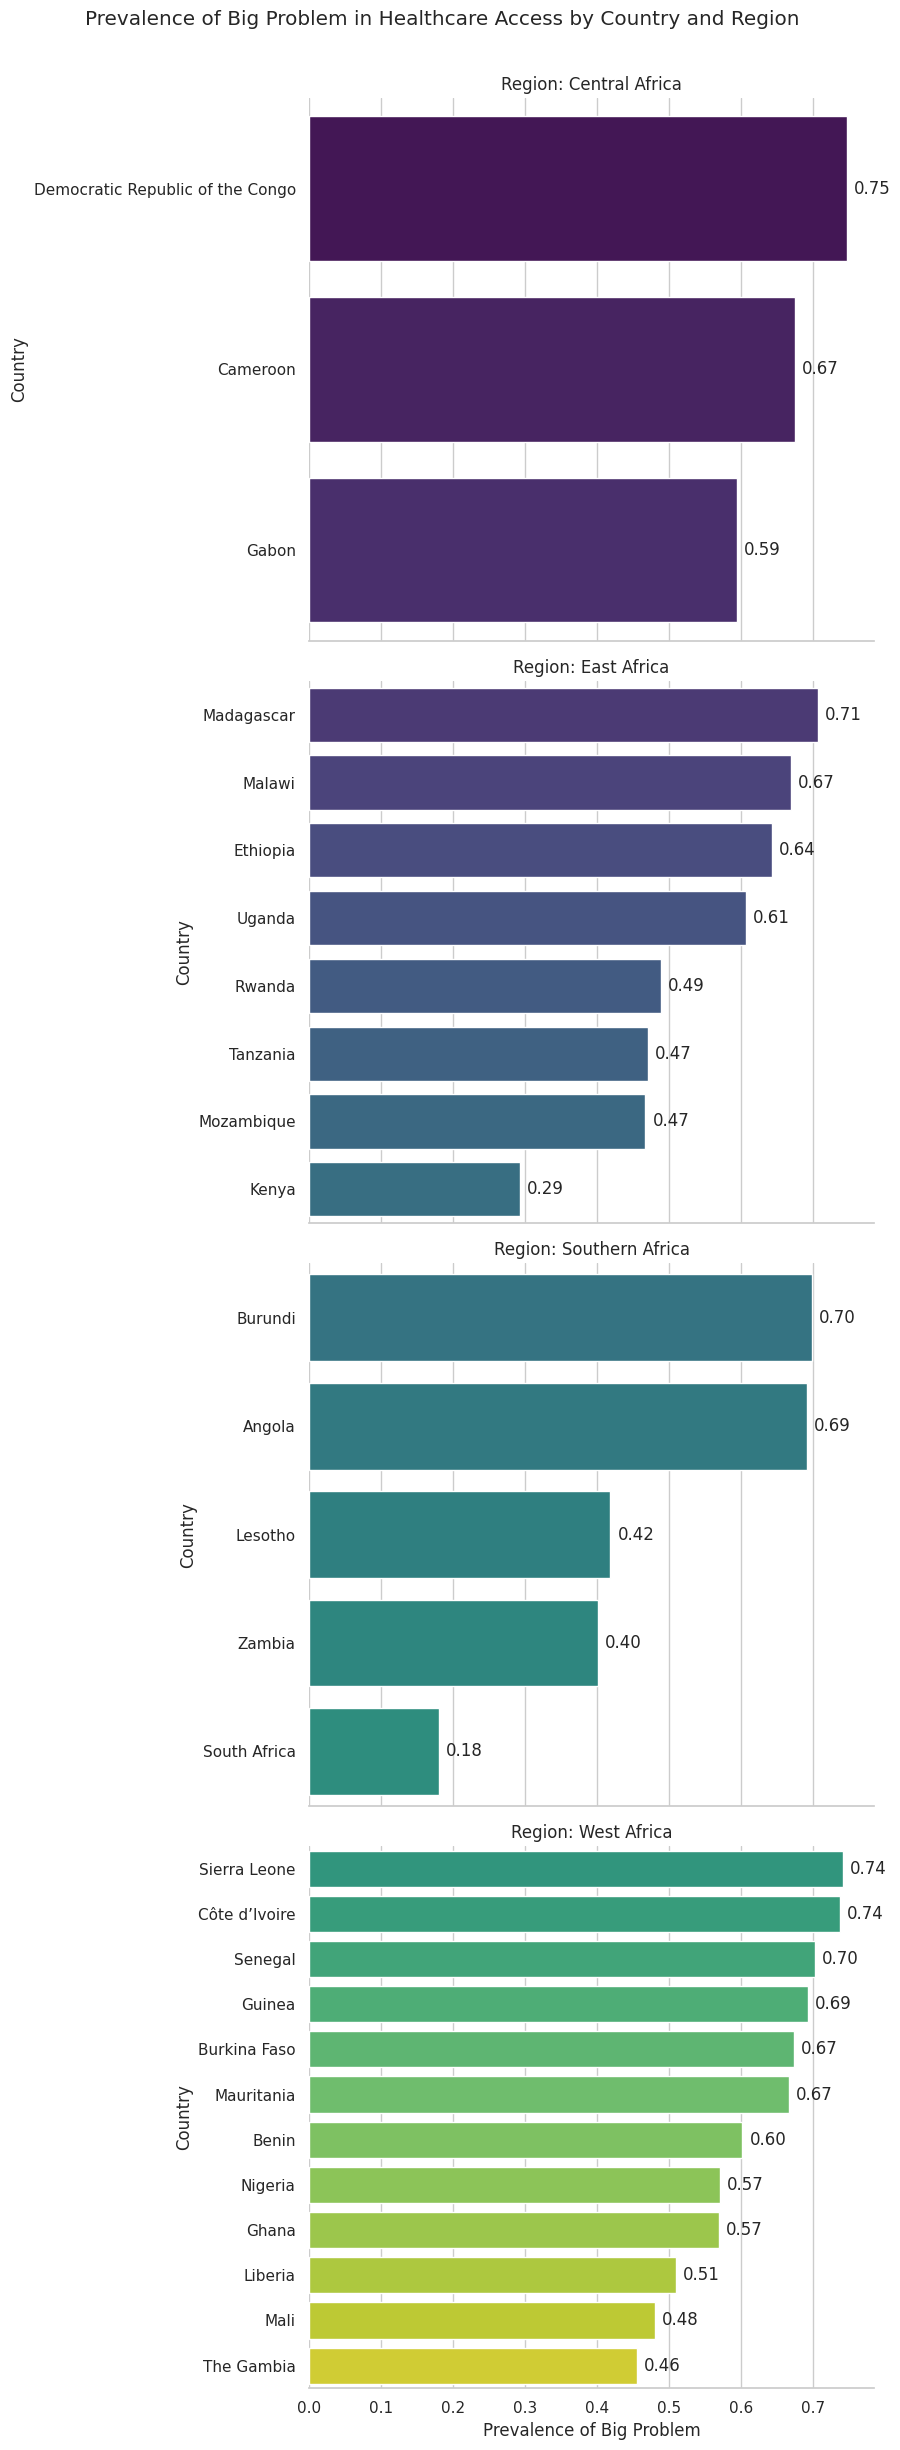

Problem_Access,Region,Country_name,big problem,not a big problem,Total,Prevalence of access problem
1,Central Africa,Democratic Republic of the Congo,20600,6983,27583,0.746837
0,Central Africa,Cameroon,9891,4786,14677,0.673912
2,Central Africa,Gabon,6557,4486,11043,0.593770
5,East Africa,Madagascar,13341,5528,18869,0.707033
6,East Africa,Malawi,16424,8138,24562,0.668675
3,East Africa,Ethiopia,10084,5599,15683,0.642989
10,East Africa,Uganda,11235,7271,18506,0.607100
8,East Africa,Rwanda,7147,7487,14634,0.488383
9,East Africa,Tanzania,7177,8077,15254,0.470500
7,East Africa,Mozambique,6156,7027,13183,0.466965


In [244]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the proportion of 'big problem' (encoded as 1) for each country
# We need to group by Region and Country_name first
problem_access_by_country = df.groupby(['Region', 'Country_name'])['Problem_Access'].value_counts(normalize=False).unstack().fillna(0)

# The columns are now 0 (not a big problem) and 1 (big problem) after encoding
# Rename columns for clarity in this temporary DataFrame
problem_access_by_country = problem_access_by_country.rename(columns={0: 'not a big problem', 1: 'big problem'})


# Calculate the total count for each country
problem_access_by_country['Total'] = problem_access_by_country['big problem'] + problem_access_by_country['not a big problem']

# Calculate the prevalence (proportion of 'big problem')
problem_access_by_country['Prevalence of access problem'] = problem_access_by_country['big problem'] / problem_access_by_country['Total']

# Reset index to make 'Region' and 'Country_name' columns
forest_plot_data = problem_access_by_country.reset_index()

# Sort the data by prevalence within each region
forest_plot_data = forest_plot_data.sort_values(by=['Region', 'Prevalence of access problem'], ascending=[True, False])


# Create the forest plot with regions
g = sns.catplot(
    data=forest_plot_data,
    x='Prevalence of access problem',
    y='Country_name',
    row='Region',
    kind='bar',
    height=6,
    aspect=1.5,
    palette='viridis',
    sharey=False # Allow y-axes to be independent for each facet
)

g.fig.suptitle('Prevalence of Big Problem in Healthcare Access by Country and Region', y=1.02) # Add a title to the figure
g.set_titles("Region: {row_name}") # Set titles for each facet
g.set_axis_labels("Prevalence of Big Problem", "Country")
g.despine(left=True)

# Add text annotations for the prevalence values on each bar
for ax in g.axes.flat:
    for p in ax.patches:
        ax.annotate(f'{p.get_width():.2f}', (p.get_width(), p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', xytext=(5, 0), textcoords='offset points')


plt.show()

# Display the table with the calculated values
display(forest_plot_data)

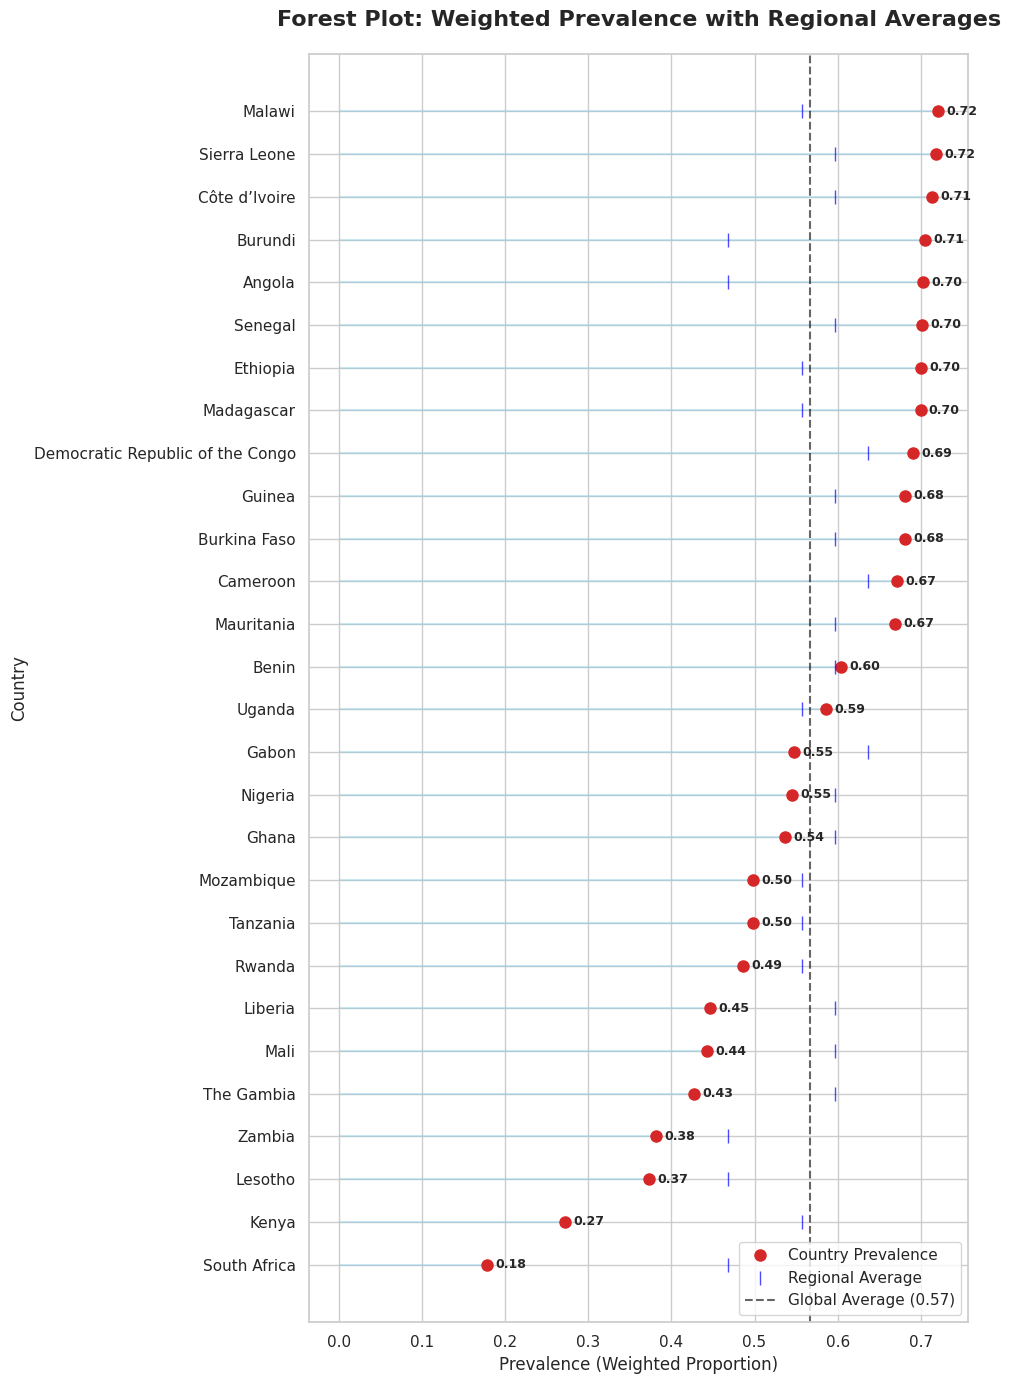


 REGIONAL WEIGHTED AVERAGES 


,Region,Region_Avg
0,Central Africa,0.637
3,West Africa,0.597
1,East Africa,0.558
2,Southern Africa,0.468



 COUNTRY-LEVEL SUMMARY 


Region,Country_name,Total_Weighted,Prevalence
Central Africa,Democratic Republic of the Congo,"27,583",0.691
Central Africa,Cameroon,"14,677",0.672
Central Africa,Gabon,"11,043",0.548
East Africa,Malawi,"24,562",0.721
East Africa,Ethiopia,"15,683",0.700
East Africa,Madagascar,"18,869",0.700
East Africa,Uganda,"18,506",0.586
East Africa,Mozambique,"13,183",0.498
East Africa,Tanzania,"15,254",0.498
East Africa,Rwanda,"14,634",0.486


In [245]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Calculate Weighted Stats by Country and Region
# We need the Region back in the grouping for the table and regional averages
weighted_counts = df.groupby(['Region', 'Country_name', 'Problem_Access'], observed=False)['Weight'].sum().unstack().fillna(0)

pos_col = 'big problem' if 'big problem' in weighted_counts.columns else 1
neg_col = 'not a big problem' if 'not a big problem' in weighted_counts.columns else 0

# Compute Prevalence
weighted_counts['Total_Weighted'] = weighted_counts[pos_col] + weighted_counts[neg_col]
weighted_counts['Prevalence'] = weighted_counts[pos_col] / weighted_counts['Total_Weighted']

plot_df = weighted_counts.reset_index().sort_values('Prevalence', ascending=True)

# 2. Calculate Regional Averages
regional_avg = plot_df.groupby('Region', observed=False)['Prevalence'].mean().reset_index()
regional_avg = regional_avg.rename(columns={'Prevalence': 'Region_Avg'})

# Merge regional average back to plot_df for plotting markers
plot_df = plot_df.merge(regional_avg, on='Region')

# 3. Create High-Quality Forest Plot with Region Markers
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 14))

# Plot horizontal lines and country points
plt.hlines(y=plot_df['Country_name'], xmin=0, xmax=plot_df['Prevalence'], color='skyblue', alpha=0.4, linewidth=1.5)
plt.plot(plot_df['Prevalence'], plot_df['Country_name'], "o", markersize=8, color='#d62728', label='Country Prevalence')

# Plot Regional Average markers
plt.plot(plot_df['Region_Avg'], plot_df['Country_name'], "|", markersize=10, color='blue', alpha=0.7, label='Regional Average')

# Global mean line
global_mean = plot_df['Prevalence'].mean()
plt.axvline(global_mean, color='black', linestyle='--', alpha=0.6, label=f'Global Average ({global_mean:.2f})')

plt.title('Forest Plot: Weighted Prevalence with Regional Averages', fontsize=16, weight='bold', pad=20)
plt.xlabel('Prevalence (Weighted Proportion)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.legend(loc='lower right', frameon=True)

# Annotations
for i, val in enumerate(plot_df['Prevalence']):
    plt.text(val + 0.01, i, f'{val:.2f}', va='center', fontsize=9, weight='semibold')

plt.tight_layout()
plt.show()

# 4. Summary Tables
print("\n" + "="*40)
print(" REGIONAL WEIGHTED AVERAGES ")
print("="*40)
display(regional_avg.sort_values('Region_Avg', ascending=False).style.format({'Region_Avg': '{:.3f}'}).background_gradient(cmap='YlOrRd'))

print("\n" + "="*65)
print(" COUNTRY-LEVEL SUMMARY ")
print("="*65)
display(plot_df[['Region', 'Country_name', 'Total_Weighted', 'Prevalence']].sort_values(['Region', 'Prevalence'], ascending=[True, False]).style.format({
    'Total_Weighted': '{:,.0f}',
    'Prevalence': '{:.3f}'
}).hide(axis='index'))

In [246]:
df.head()

,Country,Country_name,Region,v001,v005,v007,Maternal_age,highest_educational_level,Residence,sex_of_hh,...,gave_birth_in_the_5yrs,currently_pregnant,History_abortion,contraceptive_use_and_intention,visited_HF_last_12months,covered_by_health_insurance,Working_status,Weight,Problem_Access,Media exposure
0,AO7,Angola,Southern Africa,1,1086089,2016,35-49,No education,rural,male,...,Yes,no or unsure,yes,No,no,no,yes,1.086089,big problem,No
1,AO7,Angola,Southern Africa,1,1086089,2016,35-49,No education,rural,male,...,Yes,yes,no,No,no,no,yes,1.086089,not a big problem,No
2,AO7,Angola,Southern Africa,1,1086089,2016,15-24,No education,rural,male,...,Yes,yes,no,No,yes,no,yes,1.086089,big problem,No
3,AO7,Angola,Southern Africa,1,1086089,2016,35-49,Primary Education,rural,male,...,Yes,no or unsure,yes,No,no,no,yes,1.086089,big problem,No
4,AO7,Angola,Southern Africa,1,1086089,2016,25-34,No education,rural,male,...,Yes,no or unsure,no,No,no,no,yes,1.086089,not a big problem,No


In [247]:
df.columns

Index(['Country', 'Country_name', 'Region', 'v001', 'v005', 'v007',
       'Maternal_age', 'highest_educational_level', 'Residence', 'sex_of_hh',
       'owns_mobile_telephone', 'use_of_internet', 'Wealth_index',
       'gave_birth_in_the_5yrs', 'currently_pregnant', 'History_abortion',
       'contraceptive_use_and_intention', 'visited_HF_last_12months',
       'covered_by_health_insurance', 'Working_status', 'Weight',
       'Problem_Access', 'Media exposure'],
      dtype='object')

In [248]:
# Calculate missing counts and percentages
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Combine into a summary DataFrame
missing_summary = pd.DataFrame({
    'Missing Count': missing_values,
    'Percentage (%)': missing_percentage
})

# Display the summary for all columns
display(missing_summary.style.format({'Percentage (%)': '{:.2f}%'}))

,Missing Count,Percentage (%)
Country,0,0.00%
Country_name,0,0.00%
Region,0,0.00%
v001,0,0.00%
v005,0,0.00%
v007,0,0.00%
Maternal_age,5838,1.25%
highest_educational_level,0,0.00%
Residence,0,0.00%
sex_of_hh,0,0.00%


In [249]:
# Columns to impute with mode
cols_to_impute_mode = [
    'Maternal_age',
    'currently_pregnant',
    'History_abortion',
    'contraceptive_use_and_intention',
    'visited_HF_last_12months',
    'covered_by_health_insurance',
    'Working_status',
    'gave_birth_in_the_5yrs'
]

# Impute missing values with the mode for each specified column
for col in cols_to_impute_mode:
    if df[col].isnull().any():
        mode_value = df[col].mode()[0]  # Get the first mode in case of ties
        df[col] = df[col].fillna(mode_value)

# Check for missing values again to confirm imputation
display(df.isnull().sum())

,0
Country,0
Country_name,0
Region,0
v001,0
v005,0
v007,0
Maternal_age,0
highest_educational_level,0
Residence,0
sex_of_hh,0


In [250]:
df.head()

,Country,Country_name,Region,v001,v005,v007,Maternal_age,highest_educational_level,Residence,sex_of_hh,...,gave_birth_in_the_5yrs,currently_pregnant,History_abortion,contraceptive_use_and_intention,visited_HF_last_12months,covered_by_health_insurance,Working_status,Weight,Problem_Access,Media exposure
0,AO7,Angola,Southern Africa,1,1086089,2016,35-49,No education,rural,male,...,Yes,no or unsure,yes,No,no,no,yes,1.086089,big problem,No
1,AO7,Angola,Southern Africa,1,1086089,2016,35-49,No education,rural,male,...,Yes,yes,no,No,no,no,yes,1.086089,not a big problem,No
2,AO7,Angola,Southern Africa,1,1086089,2016,15-24,No education,rural,male,...,Yes,yes,no,No,yes,no,yes,1.086089,big problem,No
3,AO7,Angola,Southern Africa,1,1086089,2016,35-49,Primary Education,rural,male,...,Yes,no or unsure,yes,No,no,no,yes,1.086089,big problem,No
4,AO7,Angola,Southern Africa,1,1086089,2016,25-34,No education,rural,male,...,Yes,no or unsure,no,No,no,no,yes,1.086089,not a big problem,No


In [251]:
df.columns

Index(['Country', 'Country_name', 'Region', 'v001', 'v005', 'v007',
       'Maternal_age', 'highest_educational_level', 'Residence', 'sex_of_hh',
       'owns_mobile_telephone', 'use_of_internet', 'Wealth_index',
       'gave_birth_in_the_5yrs', 'currently_pregnant', 'History_abortion',
       'contraceptive_use_and_intention', 'visited_HF_last_12months',
       'covered_by_health_insurance', 'Working_status', 'Weight',
       'Problem_Access', 'Media exposure'],
      dtype='object')

In [252]:
variables_to_tabulate = [
    'Region',
    'Maternal_age',
    'highest_educational_level',
    'Residence',
    'sex_of_hh',
    'owns_mobile_telephone',
    'use_of_internet',
    'Wealth_index',
    'currently_pregnant',
    'History_abortion',
    'contraceptive_use_and_intention',
    'visited_HF_last_12months',
    'covered_by_health_insurance',
    'Working_status',
    'Media exposure',
    'gave_birth_in_the_5yrs'
]

# Create an empty list to store the formatted cross-tabulations
formatted_tables = []

for var in variables_to_tabulate:
    # 1. Create the weighted cross-tabulation
    cross_tab = pd.crosstab(
        index=df[var],
        columns=df['Problem_Access'],
        values=df['Weight'],
        aggfunc='sum'
    ).fillna(0)

    # 1b. Remove specific unwanted categories if they exist
    categories_to_exclude = ['9.0', 'Unknown', 9.0]
    cross_tab = cross_tab[~cross_tab.index.isin(categories_to_exclude)]

    # 2. Calculate row-wise proportions (Access Problem %)
    cross_tab_prop = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100

    # 3. Calculate Weighted Total for each Category and the entire Variable
    category_totals = cross_tab.sum(axis=1)
    variable_total = category_totals.sum()
    category_pct_of_var = (category_totals / variable_total) * 100

    # 4. Format the table for display
    temp_df = cross_tab.reset_index()
    temp_prop = cross_tab_prop.reset_index()
    temp_totals = category_totals.reset_index(name='Count')
    temp_var_pct = category_pct_of_var.reset_index(name='VarPct')

    temp_df = temp_df.rename(columns={var: 'Category'})
    temp_prop = temp_prop.rename(columns={var: 'Category'})

    # Columns for final display
    formatted_cross_tab = pd.DataFrame({
        'Variable': var,
        'Category': temp_df['Category'],
        'big problem': temp_df['big problem'].apply(lambda x: f"{x:,.0f}") + ' (' + temp_prop['big problem'].round(2).astype(str) + '%)',
        'not a big problem': temp_df['not a big problem'].apply(lambda x: f"{x:,.0f}") + ' (' + temp_prop['not a big problem'].round(2).astype(str) + '%)',
        'Total': temp_totals['Count'].apply(lambda x: f"{x:,.0f}") + ' (' + temp_var_pct['VarPct'].round(2).astype(str) + '%)'
    })

    formatted_tables.append(formatted_cross_tab)

# Concatenate all formatted tables
combined_cross_tab = pd.concat(formatted_tables, ignore_index=True)

# Display the combined table
display(combined_cross_tab)

# Save to CSV
combined_cross_tab.to_csv('weighted_cross_tabulation_final.csv', index=False)
print("\nWeighted cross-tabulation with distribution percentages (excluding 9.0/Unknown) saved to 'weighted_cross_tabulation_final.csv'")

,Variable,Category,big problem,not a big problem,Total
0,Region,Central Africa,"34,959 (65.58%)","18,344 (34.42%)","53,303 (11.39%)"
1,Region,East Africa,"82,764 (54.15%)","70,083 (45.85%)","152,847 (32.66%)"
2,Region,Southern Africa,"31,402 (52.11%)","28,856 (47.89%)","60,258 (12.88%)"
3,Region,West Africa,"120,024 (59.55%)","81,533 (40.45%)","201,557 (43.07%)"
4,Maternal_age,15-24,"108,840 (56.75%)","82,955 (43.25%)","191,796 (40.99%)"
5,Maternal_age,25-34,"80,543 (57.04%)","60,650 (42.96%)","141,193 (30.17%)"
6,Maternal_age,35-49,"79,767 (59.1%)","55,210 (40.9%)","134,977 (28.84%)"
7,highest_educational_level,No education,"89,218 (68.24%)","41,531 (31.76%)","130,749 (27.94%)"
8,highest_educational_level,Primary Education,"87,119 (62.04%)","53,294 (37.96%)","140,414 (30.01%)"
9,highest_educational_level,Secondry education and Above,"92,812 (47.16%)","103,990 (52.84%)","196,803 (42.05%)"



Weighted cross-tabulation with distribution percentages (excluding 9.0/Unknown) saved to 'weighted_cross_tabulation_final.csv'


In [253]:
for col in df.columns:
    print(f"Categories for '{col}':")
    display(df[col].unique())
    print("\n") # Add a newline for better readability

Categories for 'Country':


array(['AO7', 'BF8', 'BJ7', 'BU7', 'CD8', 'CI8', 'CM7', 'ET7', 'GA7',
       'GH8', 'GM7', 'GN7', 'KE8', 'LB7', 'LS8', 'MD7', 'ML8', 'MR7',
       'MW7', 'MZ8', 'NG8', 'RW7', 'SL7', 'SN8', 'TZ8', 'UG7', 'ZA7',
       'ZM7'], dtype=object)



Categories for 'Country_name':


array(['Angola', 'Burkina Faso', 'Benin', 'Burundi',
       'Democratic Republic of the Congo', 'Côte d’Ivoire', 'Cameroon',
       'Ethiopia', 'Gabon', 'Ghana', 'The Gambia', 'Guinea', 'Kenya',
       'Liberia', 'Lesotho', 'Madagascar', 'Mali', 'Mauritania', 'Malawi',
       'Mozambique', 'Nigeria', 'Rwanda', 'Sierra Leone', 'Senegal',
       'Tanzania', 'Uganda', 'South Africa', 'Zambia'], dtype=object)



Categories for 'Region':


...

array([1.086089, 0.21374 , 3.178604, ..., 0.742571, 0.594157, 0.691259])



Categories for 'Problem_Access':


array(['big problem', 'not a big problem'], dtype=object)



Categories for 'Media exposure':


array(['No', 'Yes'], dtype=object)

In [254]:
# Define ordinal mappings based on provided categories and their implied order
maternal_age_mapping = {'15-24': 0, '25-34': 1, '35-49': 2}
educational_level_mapping_ordinal = {'No education': 0, 'Primary Education': 1, 'Secondry education and Above': 2} # Assuming 'Unknown' is not present after previous steps
wealth_index_mapping = {'poor': 0, 'middle': 1, 'rich': 2}

# Apply ordinal encoding to appropriate columns
df['Maternal_age'] = df['Maternal_age'].map(maternal_age_mapping)
df['highest_educational_level'] = df['highest_educational_level'].map(educational_level_mapping_ordinal)
df['Wealth_index'] = df['Wealth_index'].map(wealth_index_mapping)


# Define binary mappings
problem_access_mapping = {'not a big problem': 0, 'big problem': 1}
residence_mapping = {'rural': 0, 'urban': 1}
sex_of_hh_mapping = {'female': 0, 'male': 1}
owns_mobile_telephone_mapping = {'no': 0, 'yes': 1}
binary_yes_no_mapping = {'No': 0, 'Yes': 1}
binary_yes_no_unsure_mapping = {'no or unsure': 0, 'yes': 1} # For currently_pregnant
history_abortion_mapping = {'no': 0, 'yes': 1} # Assuming 9.0 is handled
visited_HF_mapping = {'no': 0, 'yes': 1} # Assuming 9.0 is handled
covered_health_insurance_mapping = {'no': 0, 'yes': 1} # Assuming 9.0 is handled
working_status_mapping = {'no': 0, 'yes': 1} # Assuming 9.0 is handled


# Apply binary encoding to appropriate columns
df['Problem_Access'] = df['Problem_Access'].map(problem_access_mapping)
df['Residence'] = df['Residence'].map(residence_mapping)
df['sex_of_hh'] = df['sex_of_hh'].map(sex_of_hh_mapping)
df['owns_mobile_telephone'] = df['owns_mobile_telephone'].map(owns_mobile_telephone_mapping)
df['use_of_internet'] = df['use_of_internet'].map(binary_yes_no_mapping)
df['currently_pregnant'] = df['currently_pregnant'].map(binary_yes_no_unsure_mapping)
df['History_abortion'] = df['History_abortion'].map(history_abortion_mapping)
df['contraceptive_use_and_intention'] = df['contraceptive_use_and_intention'].map(binary_yes_no_mapping)
df['visited_HF_last_12months'] = df['visited_HF_last_12months'].map(visited_HF_mapping)
df['covered_by_health_insurance'] = df['covered_by_health_insurance'].map(covered_health_insurance_mapping)
df['Working_status'] = df['Working_status'].map(working_status_mapping)
df['Media exposure'] = df['Media exposure'].map(binary_yes_no_mapping)
df['gave_birth_in_the_5yrs'] = df['gave_birth_in_the_5yrs'].map(binary_yes_no_mapping)


# Identify nominal columns for one-hot encoding (Region is the only multi-category nominal)
nominal_cols_ohe = ['Region']

# Perform one-hot encoding for nominal variables and concatenate with the original df
df_encoded = pd.concat([df.drop(columns=nominal_cols_ohe), pd.get_dummies(df[nominal_cols_ohe], prefix='Region', drop_first=True)], axis=1)


# Display the head of the encoded DataFrame
display(df_encoded.head())

,Country,Country_name,v001,v005,v007,Maternal_age,highest_educational_level,Residence,sex_of_hh,owns_mobile_telephone,...,contraceptive_use_and_intention,visited_HF_last_12months,covered_by_health_insurance,Working_status,Weight,Problem_Access,Media exposure,Region_East Africa,Region_Southern Africa,Region_West Africa
0,AO7,Angola,1,1086089,2016,2,0,0,1,0,...,0,0.0,0.0,1.0,1.086089,1,0,False,True,False
1,AO7,Angola,1,1086089,2016,2,0,0,1,0,...,0,0.0,0.0,1.0,1.086089,0,0,False,True,False
2,AO7,Angola,1,1086089,2016,0,0,0,1,0,...,0,1.0,0.0,1.0,1.086089,1,0,False,True,False
3,AO7,Angola,1,1086089,2016,2,1,0,1,0,...,0,0.0,0.0,1.0,1.086089,1,0,False,True,False
4,AO7,Angola,1,1086089,2016,1,0,0,1,0,...,0,0.0,0.0,1.0,1.086089,0,0,False,True,False


In [255]:
df_encoded.columns

Index(['Country', 'Country_name', 'v001', 'v005', 'v007', 'Maternal_age',
       'highest_educational_level', 'Residence', 'sex_of_hh',
       'owns_mobile_telephone', 'use_of_internet', 'Wealth_index',
       'gave_birth_in_the_5yrs', 'currently_pregnant', 'History_abortion',
       'contraceptive_use_and_intention', 'visited_HF_last_12months',
       'covered_by_health_insurance', 'Working_status', 'Weight',
       'Problem_Access', 'Media exposure', 'Region_East Africa',
       'Region_Southern Africa', 'Region_West Africa'],
      dtype='object')

In [256]:
df_encoded = df_encoded.rename(columns={
    'sex_of_hh': 'sex_of_household_head',
    'contraceptive_use_and_intention': 'contraceptive_use',
    'Problem_Access': 'healthcare_access'
})

# Verify the change
display(df_encoded.columns)

Index(['Country', 'Country_name', 'v001', 'v005', 'v007', 'Maternal_age',
       'highest_educational_level', 'Residence', 'sex_of_household_head',
       'owns_mobile_telephone', 'use_of_internet', 'Wealth_index',
       'gave_birth_in_the_5yrs', 'currently_pregnant', 'History_abortion',
       'contraceptive_use', 'visited_HF_last_12months',
       'covered_by_health_insurance', 'Working_status', 'Weight',
       'healthcare_access', 'Media exposure', 'Region_East Africa',
       'Region_Southern Africa', 'Region_West Africa'],
      dtype='object')

In [257]:
selected_columns = [
    'Maternal_age',
    'highest_educational_level',
    'Residence',
    'sex_of_household_head',
    'owns_mobile_telephone',
    'use_of_internet',
    'Wealth_index',
    'gave_birth_in_the_5yrs',
    'currently_pregnant',
    'History_abortion',
    'contraceptive_use',
    'visited_HF_last_12months',
    'covered_by_health_insurance',
    'Working_status',
    'healthcare_access',
    'Media exposure',
    'Heatthcare_Access_problem',
    'Region_East Africa',
    'Region_Southern Africa',
    'Region_West Africa'
]

# Ensure the columns exist in df_encoded before selecting
existing_cols = [col for col in selected_columns if col in df_encoded.columns]
df_selected = df_encoded[existing_cols]

# Display the head of the selected columns DataFrame
display(df_selected.head())

,Maternal_age,highest_educational_level,Residence,sex_of_household_head,owns_mobile_telephone,use_of_internet,Wealth_index,gave_birth_in_the_5yrs,currently_pregnant,History_abortion,contraceptive_use,visited_HF_last_12months,covered_by_health_insurance,Working_status,healthcare_access,Media exposure,Region_East Africa,Region_Southern Africa,Region_West Africa
0,2,0,0,1,0,0,0,1,0,1.0,0,0.0,0.0,1.0,1,0,False,True,False
1,2,0,0,1,0,0,0,1,1,0.0,0,0.0,0.0,1.0,0,0,False,True,False
2,0,0,0,1,0,0,0,1,1,0.0,0,1.0,0.0,1.0,1,0,False,True,False
3,2,1,0,1,0,0,0,1,0,1.0,0,0.0,0.0,1.0,1,0,False,True,False
4,1,0,0,1,0,0,0,1,0,0.0,0,0.0,0.0,1.0,0,0,False,True,False


In [259]:
# Calculate and display the proportion of each category for each selected variable
for col in df_selected.columns:
    print(f"Proportion of categories for '{col}':")
    display(df_selected[col].value_counts(normalize=True))
    print("\n") # Add a newline for better readability

Proportion of categories for 'Maternal_age':


,proportion
Maternal_age,
0,0.412142
1,0.297035
2,0.290823




Proportion of categories for 'highest_educational_level':


,proportion
highest_educational_level,
2,0.403092
1,0.305213
0,0.291695




Proportion of categories for 'Residence':


...

,proportion
Region_East Africa,
False,0.673379
True,0.326621




Proportion of categories for 'Region_Southern Africa':


,proportion
Region_Southern Africa,
False,0.871234
True,0.128766




Proportion of categories for 'Region_West Africa':


,proportion
Region_West Africa,
False,0.56929
True,0.43071


In [260]:
df_selected.columns

Index(['Maternal_age', 'highest_educational_level', 'Residence',
       'sex_of_household_head', 'owns_mobile_telephone', 'use_of_internet',
       'Wealth_index', 'gave_birth_in_the_5yrs', 'currently_pregnant',
       'History_abortion', 'contraceptive_use', 'visited_HF_last_12months',
       'covered_by_health_insurance', 'Working_status', 'healthcare_access',
       'Media exposure', 'Region_East Africa', 'Region_Southern Africa',
       'Region_West Africa'],
      dtype='object')

In [261]:
# Convert relevant columns in df_selected to numeric types

# Columns that were already mapped to numeric or need conversion
cols_to_numeric = [
    'Maternal_age',
    'highest_educational_level',
    'Residence',
    'sex_of_household_head',
    'owns_mobile_telephone',
    'use_of_internet',
    'Wealth_index',
    'gave_birth_in_the_5yrs',
    'currently_pregnant',
    'History_abortion',
    'contraceptive_use',
    'visited_HF_last_12months',
    'covered_by_health_insurance',
    'Working_status',
    'healthcare_access',
    'Media exposure',
    'Region_East Africa',
    'Region_Southern Africa',
    'Region_West Africa'
]

for col in cols_to_numeric:
    # Use errors='coerce' to turn any values that cannot be converted into NaN
    if col in df_selected.columns:
        df_selected[col] = pd.to_numeric(df_selected[col], errors='coerce')

# Display the data types after conversion
print("Data types of selected columns after conversion:")
display(df_selected.dtypes)

Data types of selected columns after conversion:


/tmp/ipykernel_1158/897303695.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected[col] = pd.to_numeric(df_selected[col], errors='coerce')


,0
Maternal_age,int64
highest_educational_level,int64
Residence,int64
sex_of_household_head,int64
owns_mobile_telephone,int64
use_of_internet,int64
Wealth_index,int64
gave_birth_in_the_5yrs,int64
currently_pregnant,int64
History_abortion,float64


In [262]:
df_selected.values


array([[2, 0, 0, ..., False, True, False],
       [2, 0, 0, ..., False, True, False],
       [0, 0, 0, ..., False, True, False],
       ...,
       [1, 2, 0, ..., False, True, False],
       [0, 2, 0, ..., False, True, False],
       [0, 2, 0, ..., False, True, False]], dtype=object)

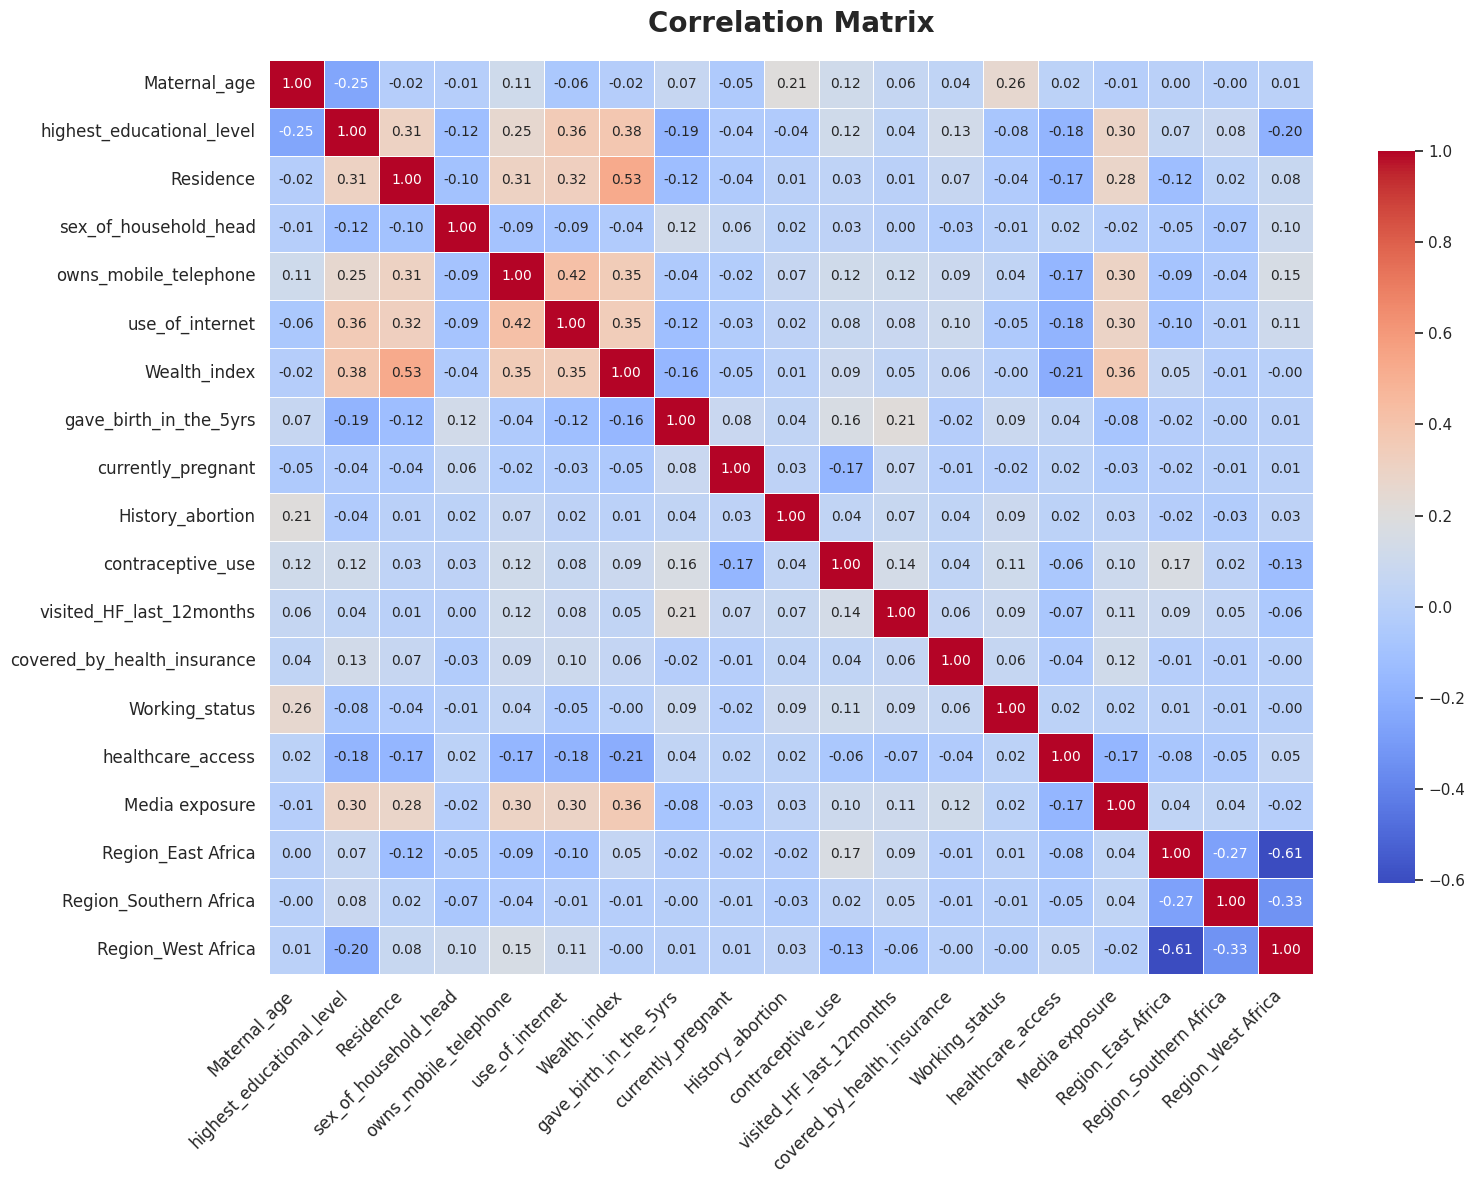

In [265]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the correlation matrix
correlation_matrix = df_selected.corr()

# 2. Set the aesthetic style for the plot
sns.set_theme(style="white")

# 3. Create the high-quality heatmap
plt.figure(figsize=(16, 12))

# Create a mask to hide the upper triangle for better clarity (optional, but often looks cleaner)
# import numpy as np
# mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

heatmap = sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 10},
    cbar_kws={"shrink": .8}
)

# 4. Enhance labels and title
plt.title('Correlation Matrix', fontsize=20, weight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)

# 5. Final adjustments for publication quality
plt.tight_layout()
plt.show()

Weighted Proportions:


,Weight
healthcare_access,
0,0.424851
1,0.575149


/tmp/ipykernel_1158/134740722.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=weighted_proportions.index, y=weighted_proportions.values, palette='viridis')


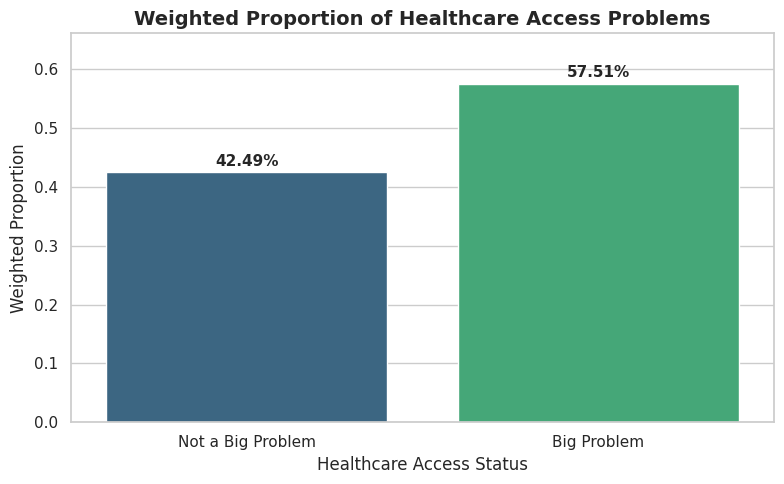

In [266]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate the weighted proportions of 'healthcare_access'
# We sum the weights for each category and divide by the total weight sum
weighted_counts = df_encoded.groupby('healthcare_access')['Weight'].sum()
weighted_proportions = weighted_counts / df_encoded['Weight'].sum()

# Display the proportions
print("Weighted Proportions:")
display(weighted_proportions)

# Create a bar plot of the weighted proportions
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(x=weighted_proportions.index, y=weighted_proportions.values, palette='viridis')

plt.title('Weighted Proportion of Healthcare Access Problems', fontsize=14, weight='bold')
plt.xlabel('Healthcare Access Status', fontsize=12)
plt.ylabel('Weighted Proportion', fontsize=12)

# Mapping the x-ticks for clarity
plt.xticks(ticks=[0, 1], labels=['Not a Big Problem', 'Big Problem'])

# Add proportion values on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=11, weight='bold')

plt.ylim(0, weighted_proportions.max() * 1.15)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Define the target variable
target = 'Problem_Access'

# Separate features (X) and target (y)
X = df_selected.drop(columns=[target])
y = df_selected[target]

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Using a random_state for reproducibility

# Display the shapes of the resulting sets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Let's balance the dataset using SMOTE and visualize the class distribution before and after to see the effect of balancing.

In [ ]:
from collections import Counter
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a figure with two subplots for side-by-side plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # Adjust figsize as needed

# Visualize class distribution before SMOTE on the first subplot
sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title('Class Distribution Before SMOTE')
axes[0].set_xlabel('Problem_Access')
axes[0].set_ylabel('Count')
axes[0].set_xticks(ticks=[0, 1], labels=['not a big problem', 'big problem']) # Assuming 0 and 1 are the encoded values

# Add proportion values on top of the bars (Before SMOTE)
total_before = len(y_train)
for p in axes[0].patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total_before)
    x = p.get_x() + p.get_width() / 2.
    y = p.get_height()
    axes[0].annotate(percentage, (x, y), ha='center', va='bottom')


# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Class distribution before SMOTE:", Counter(y_train))
print("Class distribution after SMOTE:", Counter(y_train_resampled))

# Visualize class distribution after SMOTE on the second subplot
sns.countplot(x=y_train_resampled, ax=axes[1])
axes[1].set_title('Class Distribution After SMOTE')
axes[1].set_xlabel('Problem_Access')
axes[1].set_ylabel('Count')
axes[1].set_xticks(ticks=[0, 1], labels=['not a big problem', 'big problem']) # Assuming 0 and 1 are the encoded values

# Add proportion values on top of the bars (After SMOTE)
total_after = len(y_train_resampled)
for p in axes[1].patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total_after)
    x = p.get_x() + p.get_width() / 2.
    y = p.get_height()
    axes[1].annotate(percentage, (x, y), ha='center', va='bottom')


plt.tight_layout() # Adjust layout to prevent overlapping
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE

# Step 1: Initialize the base model (Random Forest)
rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Step 2: Apply Recursive Feature Elimination (RFE)
rfe_selector = RFE(estimator=rf_base, n_features_to_select=10, step=1)
rfe_selector.fit(X_train, y_train)

# Step 3: Create DataFrame with ranking and selected features
rfe_results = pd.DataFrame({
    'Feature': X_train.columns,
    'RFE_Rank': rfe_selector.ranking_,
    'Selected': rfe_selector.support_
})

# Step 4: Sort by ranking (1 = most important)
rfe_results = rfe_results.sort_values(by='RFE_Rank', ascending=True)

# Step 5: Display summary
print("All Features Ranked by RFE Importance:")
display(rfe_results)

# Step 6: High-quality visualization including all variables
plt.figure(figsize=(10, len(rfe_results) * 0.4))  # dynamic height for clarity
sns.set(style="whitegrid", context="talk")

# Create bar plot for all variables, color by whether they were selected
# Removed hue and changed palette to a single blue color
sns.barplot(
    x='RFE_Rank',
    y='Feature',
    data=rfe_results,
    color='steelblue' # Set a single blue color
)

# Beautify the plot
plt.title('All Features Ranked by Recursive Feature Elimination (RFE)', fontsize=16, weight='bold')
plt.xlabel('RFE Rank (1 = Most Important)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
# Removed the legend
plt.gca().invert_yaxis()  # Most important at top
plt.tight_layout()

# Save high-resolution image
plt.savefig("RFE_All_Features_Ranked.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Get the names of the selected features
selected_features_names = X_train.columns[rfe_selector.support_]

# Display the selected feature names
print("Selected Features by RFE:")
display(list(selected_features_names))

# Create DataFrames with only the selected features
X_train_selected = X_train[selected_features_names]
X_test_selected = X_test[selected_features_names]


# Display the data types of the selected features
print("\nData types of Selected Features:")
display(X_train_selected.dtypes)


# Convert categorical selected features to numeric (assuming they were mapped to numeric values previously)
# Check and convert categorical features if needed in the selected DataFrames
categorical_selected_cols = X_train_selected.select_dtypes(include='category').columns

for col in categorical_selected_cols:
    # Convert to numeric, coercing errors to NaN if conversion is not possible
    X_train_selected.loc[:, col] = pd.to_numeric(X_train_selected[col], errors='coerce')
    X_test_selected.loc[:, col] = pd.to_numeric(X_test_selected[col], errors='coerce')


# Display the data types of the selected features after conversion
print("\nData types of Selected Features after conversion:")
display(X_train_selected.dtypes)

In [ ]:
X_test_selected.head()


In [ ]:
X_test_selected.values

In [ ]:
%pip install catboost

In [ ]:
# =========================================
# ⚙️ Import Libraries
# =========================================
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier
)
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="xgboost")

# =========================================
# 🚀 Define Parameter Grids
# =========================================
param_grids = {
    "AdaBoost": {
        "n_estimators": [50, 100, 200, 300],
        "learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0],
    },
    "GradientBoosting": {
        "n_estimators": [100, 200, 300],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth": [3, 4, 5],
        "subsample": [0.8, 1.0]
    },
    "XGBoost": {
        "n_estimators": [100, 200, 300],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth": [3, 4, 5, 6],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
    },
    "LightGBM": {
        "n_estimators": [100, 200, 300],
        "learning_rate": [0.01, 0.05, 0.1],
        "num_leaves": [31, 50, 100],
        "subsample": [0.8, 1.0]
    },
    "RandomForest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10]
    },
    "ExtraTrees": {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10]
    },
    "DecisionTree": {
        "max_depth": [None, 5, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "criterion": ["gini", "entropy"]
    },
    "CatBoost": {
        "iterations": [100, 200, 300],
        "learning_rate": [0.01, 0.05, 0.1],
        "depth": [4, 6, 8]
    },
    "Bagging": {
        "n_estimators": [10, 50, 100],
        "max_samples": [0.5, 0.8, 1.0],
        "max_features": [0.5, 0.8, 1.0]
    }
}

# =========================================
# 🧠 Define Models
# =========================================
models = {
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(random_state=42, enable_categorical=True, use_label_encoder=False),
    "LightGBM": lgb.LGBMClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "ExtraTrees": ExtraTreesClassifier(random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
    "Bagging": BaggingClassifier(random_state=42)
}

# =========================================
# 🔢 Ensure Correct Data Types
# =========================================
print("📊 Data types before conversion:")
display(X_train_selected.dtypes)

categorical_selected_cols = X_train_selected.select_dtypes(include='category').columns

if len(categorical_selected_cols) > 0:
    print(f"\n🔄 Converting categorical columns to numeric: {list(categorical_selected_cols)}")
    for col in categorical_selected_cols:
        X_train_selected.loc[:, col] = pd.to_numeric(X_train_selected[col], errors='coerce')
        X_test_selected.loc[:, col] = pd.to_numeric(X_test_selected[col], errors='coerce')

print("\n✅ Data types after conversion:")
display(X_train_selected.dtypes)

# =========================================
# 🔍 Tune Models Using RandomizedSearchCV
# =========================================
best_models = []
results = []

categorical_features_indices = [
    i for i, col in enumerate(X_train_selected.columns)
    if X_train_selected[col].dtype.name == 'category'
]

for name, model in models.items():
    print(f"\n🔹 Tuning {name}...")
    grid = param_grids[name]

    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=grid,
        n_iter=10,
        scoring="f1",
        cv=5,
        verbose=1,
        n_jobs=-1,
        random_state=42
    )

    if name == "CatBoost":
        random_search.fit(X_train_selected, y_train, cat_features=categorical_features_indices)
    else:
        random_search.fit(X_train_selected, y_train)

    best_model = random_search.best_estimator_
    best_models.append(best_model)

    results.append({
        "Model": name,
        "Best_Params": random_search.best_params_,
        "Best_Score": random_search.best_score_
    })

    print(f"✅ Best {name} Parameters: {random_search.best_params_}")
    print(f"🏆 Best {name} F1 Score: {random_search.best_score_:.4f}")

# =========================================
# 📊 Summarize All Results
# =========================================
results_df = pd.DataFrame(results).sort_values(by="Best_Score", ascending=False)
print("\n🎯 Model Tuning Summary:")
display(results_df)

print("\n🎉 All models tuned and trained successfully!")


In [ ]:
# =========================================
# 📊 Evaluate Tuned Models and Summarize
# =========================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import pandas as pd

# Convert best_models list to dictionary
best_models_dict = {results[i]["Model"]: best_models[i] for i in range(len(results))}

# Dictionary to store evaluation results
evaluation_results = {}

# Loop through all models
for model_name, model in best_models_dict.items():
    print(f"\n🔹 Evaluating {model_name}...")

    # Predictions
    y_pred = model.predict(X_test_selected)

    # Probabilities for ROC-AUC if available
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_selected)[:, 1]
    else:
        y_prob = None

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None

    # Store metrics
    evaluation_results[model_name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    }

# Convert to DataFrame and sort by F1-Score
evaluation_df = pd.DataFrame(evaluation_results).T.sort_values(by="F1-Score", ascending=False)

print("\n🎯 Model Evaluation Summary:")
display(evaluation_df)

# Detailed report for the best model
best_model_name = evaluation_df['F1-Score'].idxmax()
best_model = best_models_dict[best_model_name]
y_pred_best = best_model.predict(X_test_selected)

print(f"\n🔍 Detailed Report for Best Model: {best_model_name}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

# Plot F1-Score comparison
plt.figure(figsize=(10,6))
evaluation_df["F1-Score"].plot(kind="bar", color="skyblue")
plt.title("Model Comparison Based on F1-Score")
plt.ylabel("F1-Score")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [ ]:
# Exclude XGBoost from the evaluation DataFrame
evaluation_df_no_xgb = evaluation_df[evaluation_df.index != 'XGBoost']

# Display the evaluation summary excluding XGBoost
print("🎯 Model Evaluation Summary (Excluding XGBoost):")
display(evaluation_df_no_xgb)

# Save the evaluation summary excluding XGBoost to a CSV file
evaluation_df_no_xgb.to_csv('model_evaluation_summary_no_xgb.csv', index=True)

print("\nModel evaluation summary excluding XGBoost saved as 'model_evaluation_summary_no_xgb.csv'")

In [ ]:
import shap
import xgboost as xgb

print(f"SHAP version: {shap.__version__}")
print(f"XGBoost version: {xgb.__version__}")

In [ ]:
# =========================================
# 🔹 SHAP Analysis for the Second Best Model (Excluding XGBoost)
# =========================================
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Assuming 'evaluation_df' and 'best_models_dict' are available from previous cells

# Find the best model excluding XGBoost
evaluation_df_no_xgb = evaluation_df[evaluation_df.index != 'XGBoost']
if evaluation_df_no_xgb.empty:
    print("❌ No other models available for SHAP analysis after excluding XGBoost.")
else:
    second_best_model_name = evaluation_df_no_xgb['F1-Score'].idxmax()
    second_best_model = best_models_dict[second_best_model_name]
    print(f"🔹 Performing SHAP analysis for the second best model: {second_best_model_name}")

    # Ensure X_test_selected is a pandas DataFrame and handle potential non-numeric types
    if not isinstance(X_test_selected, pd.DataFrame):
        X_test_selected = pd.DataFrame(X_test_selected, columns=X_train_selected.columns) # Assuming column names are consistent

    # Ensure all columns in X_test_selected are numeric and create a copy to avoid SettingWithCopyWarning
    X_test_selected = X_test_selected.copy() # Create a copy
    for col in X_test_selected.columns:
        X_test_selected[col] = pd.to_numeric(X_test_selected[col], errors='coerce')

    # Drop any columns that could not be converted to numeric (if any)
    X_test_selected = X_test_selected.dropna(axis=1)


    # Check if the selected model is compatible with TreeExplainer
    if hasattr(second_best_model, 'feature_importances_') or hasattr(second_best_model, 'get_booster'):
        explainer = shap.TreeExplainer(second_best_model)
        # Check if shap_values is a list (for multi-output models like LightGBM)
        shap_values = explainer.shap_values(X_test_selected)
        if isinstance(shap_values, list):
           # For binary classification, use the shap values for the positive class (usually index 1)
           shap_values = shap_values[1]


        # =========================================
        # 🌟 SHAP Summary Plot (Beeswarm)
        # =========================================
        print("\n🔹 SHAP Summary (Beeswarm) Plot:")
        shap.summary_plot(shap_values, X_test_selected, plot_type="dot")
        plt.title('SHAP Beeswarm Plot')
        plt.show()


        # =========================================
        # 📊 SHAP Feature Importance (Bar Plot)
        # =========================================
        print("\n🔹 SHAP Feature Importance (Bar Plot):")
        shap.summary_plot(shap_values, X_test_selected, plot_type="bar")
        plt.title('SHAP Bar Plot (Feature Importance)')
        plt.show()


        # Optional: create DataFrame of mean absolute SHAP values
        shap_df = pd.DataFrame({
            "Feature": X_test_selected.columns,
            "Mean_Abs_SHAP": np.abs(shap_values).mean(axis=0)
        }).sort_values(by="Mean_Abs_SHAP", ascending=False)

        print("\nTop Features by SHAP Importance:")
        display(shap_df)

    else:
        print(f"❌ SHAP TreeExplainer is not compatible with {second_best_model_name}.")
        print("Please select a tree-based model for SHAP analysis.")